# 01. Dataset Preparation and Descriptive Statistics 'Deals (Done).xlsx'

**How to use this notebook:**
- make a copy for each dataset: `01_data_prepare_deals.ipynb`, `01_data_prepare_calls.ipynb`, etc.
- fill in the config cell in each copy and go through all the steps
- write insights and decisions directly into the markdown cells

---
Tasks:   
`Data cleaning and preparation:`
1. Remove duplicates and irrelevant columns.
2. Handle missing values appropriately.
3. Convert data types for columns such as dates and numeric
values.

`Descriptive statistics:`
1. Calculate summary statistics (mean, median, mode,
range) for numeric fields.
2. Analyze categorical fields such as quality, stage, source, and
product.

---
## 1. Imports & Setup

In [1]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt

import re
import helpers as h

In [2]:
# Visualization settings
sns.set_style('whitegrid')
sns.set_palette('deep')

# Pandas settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Paths (notebook lives in notebooks/, data lives in data/)
PROJECT_ROOT = Path().resolve().parent
RAW          = PROJECT_ROOT / 'data' / 'raw'
PROCESSED    = PROJECT_ROOT / 'data' / 'processed'
BACKUP       = PROJECT_ROOT / 'data' / 'processed' / 'backup'
IMAGES       = PROJECT_ROOT / 'images'

# Create the backup folder if it doesn't exist yet
BACKUP.mkdir(parents=True, exist_ok=True)

---
## 2. Dataset Configuration for 'Deals (Done).xlsx'

Fill in `name` and `filename` **before running** the rest of the cells.

In [3]:
# ── DATASET CONFIG ──────────────────────────────────────────────────────────
# Fill in name and filename - the rest comes after preliminary analysis

dataset_config = {

    # Short dataset name (Latin letters, no spaces)
    # Used as the file name when saving the config and backups
    # Examples: 'deals', 'contacts', 'calls', 'spend'
    'name':       'deals',

    # Source file name in the data/raw/ folder
    'filename':   'Deals (Done).xlsx',
    'config_pkl': 'config_deals.pkl',
    'data_pkl':   'deals_cleaned.pkl'
}

print(f"Dataset: {dataset_config['name']}")
print(f"File:    {dataset_config['filename']}")

Dataset: deals
File:    Deals (Done).xlsx


---
## 3. Loading Data

In [4]:
# Load the dataset by filename from the config
filepath = RAW / dataset_config['filename']

# Determine format from the file extension
if filepath.suffix == '.xlsx':
    df = pd.read_excel(filepath, dtype={'Id': str, 'Contact Name': str})
else:
    raise ValueError(f"Unsupported file format: {filepath.suffix}")

print(f"Loaded: {dataset_config['filename']}")
df_size_prev = (f"Original dataset size:   {df.shape[0]:_} rows × {df.shape[1]} columns")
print(df_size_prev)

Loaded: Deals (Done).xlsx
Original dataset size:   21_595 rows × 23 columns


In [5]:
# Load the cleaned contacts ('contacts_cleaned.pkl') and calls ('calls_cleaned.pkl') datasets
contacts = pd.read_pickle(PROCESSED / 'contacts_cleaned.pkl')
calls = pd.read_pickle(PROCESSED / 'calls_cleaned.pkl')

---
## 4. Preliminary Analysis


In [6]:
# First rows
df.head()

,Id,Deal Owner Name,Closing Date,Quality,Stage,Lost Reason,Page,Campaign,SLA,Content,Term,Source,Payment Type,Product,Education Type,Created Time,Course duration,Months of study,Initial Amount Paid,Offer Total Amount,Contact Name,City,Level of Deutsch
0,5805028000056864695,Ben Hall,NaN,NaN,New Lead,NaN,/eng/test,03.07.23women,NaN,v16,women,Facebook Ads,NaN,NaN,NaN,21.06.2024 15:30,NaN,NaN,NaN,NaN,5805028000056849495,NaN,NaN
1,5805028000056859489,Ulysses Adams,NaN,NaN,New Lead,NaN,/at-eng,NaN,NaN,NaN,NaN,Organic,NaN,Web Developer,Morning,21.06.2024 15:23,6.00,NaN,0,2000,5805028000056834471,NaN,NaN
2,5805028000056832357,Ulysses Adams,21.06.2024,D - Non Target,Lost,Non target,/at-eng,engwien_AT,00:26:43,b1-at,21_06_2024,Telegram posts,NaN,NaN,NaN,21.06.2024 14:45,NaN,NaN,NaN,NaN,5805028000056854421,NaN,NaN
3,5805028000056824246,Eva Kent,21.06.2024,E - Non Qualified,Lost,Invalid number,/eng,04.07.23recentlymoved_DE,01:00:04,bloggersvideo14com,recentlymoved,Facebook Ads,NaN,NaN,NaN,21.06.2024 13:32,NaN,NaN,NaN,NaN,5805028000056889351,NaN,NaN
4,5805028000056873292,Ben Hall,21.06.2024,D - Non Target,Lost,Non target,/eng,discovery_DE,00:53:12,website,NaN,Google Ads,NaN,NaN,NaN,21.06.2024 13:21,NaN,NaN,NaN,NaN,5805028000056876176,NaN,NaN


In [7]:
# Last rows
df.tail(5)

,Id,Deal Owner Name,Closing Date,Quality,Stage,Lost Reason,Page,Campaign,SLA,Content,Term,Source,Payment Type,Product,Education Type,Created Time,Course duration,Months of study,Initial Amount Paid,Offer Total Amount,Contact Name,City,Level of Deutsch
21590,5805028000000945016,Jane Smith,29.08.2023,A - High,Lost,Changed Decision,eng/digital-marketing,02.07.23wide_DE,"56 days, 19:01:59",b3,wide,Facebook Ads,NaN,NaN,NaN,03.07.2023 20:39,NaN,NaN,NaN,NaN,5805028000000968001,NaN,NaN
21591,5805028000000927004,Bob Brown,09.07.2023,D - Non Target,Lost,Does not speak English,eng/digital-marketing,03.07.23women,NaN,b3,women,Facebook Ads,NaN,NaN,NaN,03.07.2023 20:17,NaN,NaN,NaN,NaN,5805028000000961001,NaN,NaN
21592,5805028000000922001,Bob Brown,03.07.2023,E - Non Qualified,Lost,Refugee,/,NaN,"4 days, 22:47:14",NaN,NaN,Organic,NaN,NaN,NaN,03.07.2023 17:03,NaN,NaN,0,0,5805028000001009140,NaN,NaN
21593,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21594,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,#REF!,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Cleaning Up Dataset Field Names

In [8]:
# Rename columns: strip whitespace and parentheses, convert to snake_case
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')

print("Columns after renaming:")
print(df.columns.tolist())

Columns after renaming:
['id', 'deal_owner_name', 'closing_date', 'quality', 'stage', 'lost_reason', 'page', 'campaign', 'sla', 'content', 'term', 'source', 'payment_type', 'product', 'education_type', 'created_time', 'course_duration', 'months_of_study', 'initial_amount_paid', 'offer_total_amount', 'contact_name', 'city', 'level_of_deutsch']


In [9]:
# Rename specific columns
df.rename(columns={'id': 'deals_id', 'contact_name': 'contact_id', 'term': 'ad_group', 'content': 'ad' }, inplace=True)
print("\nFirst rows of the DataFrame after renaming the field:")
df.head(3)


First rows of the DataFrame after renaming the field:


,deals_id,deal_owner_name,closing_date,quality,stage,lost_reason,page,campaign,sla,ad,ad_group,source,payment_type,product,education_type,created_time,course_duration,months_of_study,initial_amount_paid,offer_total_amount,contact_id,city,level_of_deutsch
0,5805028000056864695,Ben Hall,NaN,NaN,New Lead,NaN,/eng/test,03.07.23women,NaN,v16,women,Facebook Ads,NaN,NaN,NaN,21.06.2024 15:30,NaN,NaN,NaN,NaN,5805028000056849495,NaN,NaN
1,5805028000056859489,Ulysses Adams,NaN,NaN,New Lead,NaN,/at-eng,NaN,NaN,NaN,NaN,Organic,NaN,Web Developer,Morning,21.06.2024 15:23,6.00,NaN,0,2000,5805028000056834471,NaN,NaN
2,5805028000056832357,Ulysses Adams,21.06.2024,D - Non Target,Lost,Non target,/at-eng,engwien_AT,00:26:43,b1-at,21_06_2024,Telegram posts,NaN,NaN,NaN,21.06.2024 14:45,NaN,NaN,NaN,NaN,5805028000056854421,NaN,NaN


### Dataset Description

|Column name  | Description |   
|------------------|----------|  
| **deals_id** | Deal ID  
| **deal_owner_name** | Sales manager handling this deal (one customer can have several deals) |   
| **closing_date** | Closing date = date the money arrived = payment done |    
| **quality** | Deal-quality classification indicating its potential or target status; filled in subjectively by the sales manager |  | on an ABCDE scale | where A is the hottest lead, E is an unqualified lead (bad data or no contact made) |      
| **stage** | Current deal stage. Status 'payment done' means the deal has been paid. |    
| **lost_reason** | Reason the customer declined to buy and moved to the Lost stage |   
| **page** | Website page the application was submitted from |    
| **campaign** | Shows which ad campaign the lead came from. |   
| **sla** | SLA is the sales rep's response time to an application, i.e. how much time passed from the lead submitting the application to a rep contacting them | |   
| **ad** | (content)	Shows which ad the lead came from |   
| **ad_group** | (term)	Shows which ad group the lead came from |   
| **source** | Shows which advertising channel the lead came from |   
| **payment_type** | Customer's payment method |   
| **product** | Product the customer bought, or is considering buying |   
| **education_type** | Study format suited to the customer |   
| **created_time** | Deal creation time |   
| **course_duration** | Course duration in months |   
| **months_of_study** | How long the student has been studying up to now (the moment the dataset was created); we can't tell whether they are still studying |    
| **initial_amount_paid** | How much the customer paid in the first payment; can be the full tuition or only part of it |   
| **offer_total_amount** | Full tuition per the contract (how much the customer will pay if they finish and make all payments) |   
| **contact_id** | Contact ID from the Contacts table |   
| **city** | Customer's city |   
| **level_of_deutsch** | Customer's language level |

In [10]:
# Size and column dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21595 entries, 0 to 21594
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   deals_id             21593 non-null  object 
 1   deal_owner_name      21564 non-null  object 
 2   closing_date         14645 non-null  object 
 3   quality              19340 non-null  object 
 4   stage                21593 non-null  object 
 5   lost_reason          16124 non-null  object 
 6   page                 21593 non-null  object 
 7   campaign             16067 non-null  object 
 8   sla                  15533 non-null  object 
 9   ad                   14147 non-null  object 
 10  ad_group             12454 non-null  object 
 11  source               21593 non-null  object 
 12  payment_type         496 non-null    object 
 13  product              3592 non-null   object 
 14  education_type       3300 non-null   object 
 15  created_time         21593 non-null 

In [11]:
df.describe(include='all')

,deals_id,deal_owner_name,closing_date,quality,stage,lost_reason,page,campaign,sla,ad,ad_group,source,payment_type,product,education_type,created_time,course_duration,months_of_study,initial_amount_paid,offer_total_amount,contact_id,city,level_of_deutsch
count,21593,21564,14645,19340,21593,16124,21593,16067,15533,14147,12454,21593,496,3592,3300,21593,3587.00,840.00,4165.00,4185.00,21532,2511,1251
unique,21593,27,359,6,13,21,34,154,13357,187,220,13,3,5,3,20334,NaN,NaN,24.00,21.00,18089,876,215
top,5805028000056864695,Charlie Davis,02.04.2024,E - Non Qualified,Lost,Doesn't Answer,/eng,performancemax_digitalmarkt_ru_DE,00:10:46,_{region_name}_,wide,Facebook Ads,Recurring Payments,Digital Marketing,Morning,01.01.2024 21:46,NaN,NaN,1000.00,11000.00,5805028000003014152,-,B1
freq,1,2963,119,7634,15743,4135,5814,2653,6,3258,3675,4850,350,1990,2895,50,NaN,NaN,2623.00,1860.00,54,348,219
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.20,5.44,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.83,2.92,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.00,0.00,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.00,3.00,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.00,5.00,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.00,8.00,NaN,NaN,NaN,NaN,NaN


In [12]:
# Summary table for numeric columns 
h.descr_df(df)

,Column name,Dtype,Value count,Missing (NaN),Unique values,Min,Q1,Mean,Q2 Median,Q3,Max,Range,IQR
0,course_duration,float64,3587,18008,2,6.00,11.00,10.20,11.00,11.00,11.00,5.00,0.00
1,months_of_study,float64,840,20755,12,0.00,3.00,5.44,5.00,8.00,11.00,11.00,5.00


In [13]:
# Summary table for categorical columns 
h.descr_df(df, include=['object'], show_stats=False, show_sample_rows=True)

,Column name,Dtype,Value count,Missing (NaN),Unique values,Sample row 1,Sample row 2,Sample row 3
0,deals_id,object,21593,2,21593,5805028000056864695,5805028000056859489,5805028000056832357
1,deal_owner_name,object,21564,31,27,Ben Hall,Ulysses Adams,Ulysses Adams
2,closing_date,object,14645,6950,359,NaN,NaN,21.06.2024
3,quality,object,19340,2255,6,NaN,NaN,D - Non Target
4,stage,object,21593,2,13,New Lead,New Lead,Lost
5,lost_reason,object,16124,5471,21,NaN,NaN,Non target
6,page,object,21593,2,34,/eng/test,/at-eng,/at-eng
7,campaign,object,16067,5528,154,03.07.23women,NaN,engwien_AT
8,sla,object,15533,6062,13357,NaN,NaN,00:26:43
9,ad,object,14147,7448,187,v16,NaN,b1-at


In [14]:
# Missing values - first look
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

missing_df = pd.DataFrame({'missing': missing, '%': missing_pct})
missing_df = missing_df.query('missing > 0').sort_values('%', ascending=False)

if missing_df.empty:
    print("No missing values")
else:
    display(missing_df)

,missing,%
payment_type,21099,97.70
months_of_study,20755,96.10
level_of_deutsch,20344,94.20
city,19084,88.40
education_type,18295,84.70
course_duration,18008,83.40
product,18003,83.40
initial_amount_paid,17430,80.70
offer_total_amount,17410,80.60
ad_group,9141,42.30


In [15]:
# Full duplicate rows - first look
n_dups = df.duplicated().sum()
print(f"Duplicate rows: {n_dups}")

Duplicate rows: 0


**Dataset description:** 

Our 'Deals (Done)' dataset has 21_595 observations and 23 variables.   
Some columns have missing values.

**Insights:** 

1) On load, column types were changed: 'Id' -> str, 'Contact Name' -> str - to avoid precision loss.
2) Column names came with capital letters, spaces and parentheses -> converted to snake_case, no spaces.
3) Column names were changed for consistency with the other datasets:   
   'Id' -> 'deals_id', 'Contact Name' -> 'contact_id', 'Term' -> 'ad_group', 'Content' -> 'ad'
4) 'closing_date', 'created_time' - object dtype, convert to datetime64[ns].
5) 'sla' -> Timedelta
6) 'course_duration', 'months_of_study', 'initial_amount_paid', 'offer_total_amount' -> converted to numeric
7) Some columns have missing values - need detailed handling.
8) For categorical variables where the number of unique values < the square root of the dataset size (146), convert the type to 'category'.

---
## 5. Refining the Config: Column Types

Fill in the lists based on the preliminary analysis above.  
After filling them in, run the cell - the config will be saved.

In [16]:
num_cols = list(df.select_dtypes(include='number').columns)
print(num_cols)

['course_duration', 'months_of_study']


In [17]:
cat_cols = list(df.select_dtypes(include='object').columns)
print(cat_cols)

['deals_id', 'deal_owner_name', 'closing_date', 'quality', 'stage', 'lost_reason', 'page', 'campaign', 'sla', 'ad', 'ad_group', 'source', 'payment_type', 'product', 'education_type', 'created_time', 'initial_amount_paid', 'offer_total_amount', 'contact_id', 'city', 'level_of_deutsch']


In [18]:
bool_cols = list(df.select_dtypes(include='bool').columns)
print(bool_cols)

[]


In [19]:
date_cols = list(df.select_dtypes(include='datetime').columns)
print(date_cols)

[]


In [20]:
# Fill in the lists based on Section 4's results ONCE, then run the code and comment it out
# If a column was already loaded from a saved config, it's fine to leave as-is

dataset_config['num_cols'] = [
    # Numeric: sla, initial_amount_paid, offer_total_amount, ...
     'course_duration', 'months_of_study', 'initial_amount_paid', 'offer_total_amount'
    # *num_cols,
]

dataset_config['cat_cols'] = [
    # Categorical: stage, source, product, quality, ...
    'deal_owner_name', 'quality', 'stage', 'lost_reason', 'page', 'ad', 'content', 'ad_group', 'source',
     'payment_type', 'product', 'education_type', 'city', 'level_of_deutsch',   
    # *cat_cols,
]

dataset_config['bool_cols'] = [
    # Boolean (True/False or 0/1): e.g. scheduled_in_crm
    # '',
    *bool_cols
]

dataset_config['date_cols'] = [
    # Dates: created_time, closing_date, ...
    'closing_date', 'created_time',  
    # *date_cols
]

dataset_config['drop_cols'] = [
    # Columns definitely not needed for analysis
    '',
]

# Remove empty placeholder strings from the lists
for key in ['num_cols', 'cat_cols', 'bool_cols', 'date_cols', 'drop_cols']:
    dataset_config[key] = [col for col in dataset_config[key] if col]

print("Config ready:")
print("=" * 50)
for key, val in dataset_config.items():
    print(f"  {key}: {val}")

Config ready:
  name: deals
  filename: Deals (Done).xlsx
  config_pkl: config_deals.pkl
  data_pkl: deals_cleaned.pkl
  num_cols: ['course_duration', 'months_of_study', 'initial_amount_paid', 'offer_total_amount']
  cat_cols: ['deal_owner_name', 'quality', 'stage', 'lost_reason', 'page', 'ad', 'content', 'ad_group', 'source', 'payment_type', 'product', 'education_type', 'city', 'level_of_deutsch']
  bool_cols: []
  date_cols: ['closing_date', 'created_time']
  drop_cols: []


**Insights:**

'closing_date', 'created_time' - dtype was object -> converted to datetime64[ns].   
'course_duration', 'months_of_study', 'initial_amount_paid', 'offer_total_amount' -> converted to numeric

### Saving the Config and Dataset to pkl

In [21]:
# Force id -> string
# to be sure the dtype doesn't shift (needed for merges)

id_cols = ['deals_id', 'contact_id'] 

for col in id_cols:
    if col in df.columns:
        df[col] = df[col].astype('string')
        
# Save the CONFIG to pkl
sufix = 'config'
config_path = PROCESSED /  f"{sufix}_{dataset_config['name']}.pkl"

with open(config_path, "wb") as f:
    pickle.dump(dataset_config, f)
print(f"Config saved: {config_path.relative_to(PROJECT_ROOT)}")

# Save the DATASET to pkl
dataset_path = PROCESSED / f"{dataset_config['name']}_cleaned.pkl"    
df.to_pickle(dataset_path)

print(f"Dataset saved: {dataset_path.relative_to(PROJECT_ROOT)}")
print(f"Size: {df.shape[0]:_} × {df.shape[1]}")
print(f"{'─'*60}")
print(f"ID types: { {col: df[col].dtype for col in id_cols if col in df} }")

Config saved: data\processed\config_deals.pkl
Dataset saved: data\processed\deals_cleaned.pkl
Size: 21_595 × 23
────────────────────────────────────────────────────────────
ID types: {'deals_id': string[python], 'contact_id': string[python]}


---
## 6. Converting Data Types

### Datetime Columns

In [22]:
# Look at the stats for the columns to be converted, before conversion
cols = ['created_time', 'closing_date', 'sla']
h.colls_stats(df, cols)

,Column name,Dtype,Value count,Missing (NaN),Missing %,Non-missing,Non-missing %,Unique
0,created_time,object,21593,2,0.01,21593,99.99,20334
1,closing_date,object,14645,6950,32.18,14645,67.82,359
2,sla,object,15533,6062,28.07,15533,71.93,13357


In [23]:
# Convert dates
for col in dataset_config['date_cols']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], dayfirst=True, errors='coerce') # dayfirst=True -> European format
        print(f"  {col} -> datetime {df[col].dtype}")

  closing_date -> datetime datetime64[ns]
  created_time -> datetime datetime64[ns]


In [24]:
# Create a 'created_date' column containing only the date, format='%d.%m.%Y'
col = 'created_time'
df['created_date'] = pd.to_datetime(df[col].dt.date, format='%d.%m.%Y')
df['created_date'].head(3)

0   2024-06-21
1   2024-06-21
2   2024-06-21
Name: created_date, dtype: datetime64[ns]

In [25]:
# Handle sla as a duration (the source column holds a time value - Timedelta)
if 'sla' in df.columns:
    df['sla'] = pd.to_timedelta(df['sla'].astype(str), errors='coerce')
    print(f"sla converted to timedelta. Example: {df['sla'].iloc[0:5]}")

sla converted to timedelta. Example: 0               NaT
1               NaT
2   0 days 00:26:43
3   0 days 01:00:04
4   0 days 00:53:12
Name: sla, dtype: timedelta64[ns]


In [26]:
# Look at the column stats after conversion
cols = ['created_time', 'closing_date', 'sla']
h.colls_stats(df, cols)

,Column name,Dtype,Value count,Missing (NaN),Missing %,Non-missing,Non-missing %,Unique
0,created_time,datetime64[ns],21593,2,0.01,21593,99.99,20334
1,closing_date,datetime64[ns],14645,6950,32.18,14645,67.82,359
2,sla,timedelta64[ns],15533,6062,28.07,15533,71.93,13357


No data lost when converting the time columns

### Numeric Columns

In [27]:
# Look at the column stats before conversion
cols = ['course_duration', 'months_of_study', 'offer_total_amount', 'initial_amount_paid']
h.colls_stats(df, cols)

,Column name,Dtype,Value count,Missing (NaN),Missing %,Non-missing,Non-missing %,Unique
0,course_duration,float64,3587,18008,83.39,3587,16.61,2
1,months_of_study,float64,840,20755,96.11,840,3.89,12
2,offer_total_amount,object,4185,17410,80.62,4185,19.38,21
3,initial_amount_paid,object,4165,17430,80.71,4165,19.29,24


In [28]:
# # Clean format errors in the money columns, where numbers appear with a currency ($11.500.00 or € 2.900,00) and periods

def clean_currency_pro(value):
    # 1. If empty - return NaN; zero is kept (important for 0-amount deals - demo access)
    if pd.isna(value) or str(value).strip() in ['nan', 'None', '']:
        return np.nan 
    
    s = str(value).replace('€', '').replace('$', '').replace(' ', '').strip()
    
    # 2. Handle periods and commas
    # If both a period and a comma are present (2.900,00)
    if ',' in s and '.' in s:
        s = s.replace('.', '').replace(',', '.')
    # If only a comma (2900,00)
    elif ',' in s:
        s = s.replace(',', '.')
    # If only a period (11.500) - usually a thousands separator in Europe
    # But if there are 2 digits after the period (11.50), it's cents. 
    
    elif '.' in s and len(s.split('.')[-1]) > 2:
        s = s.replace('.', '')
        
    try:
        return float(s)
    except:
        return np.nan

# Apply to the 'offer_total_amount' and 'initial_amount_paid' columns
df['offer_total_amount'] = df['offer_total_amount'].apply(clean_currency_pro)
df['initial_amount_paid'] = df['initial_amount_paid'].apply(clean_currency_pro)

In [29]:
# Convert numeric columns
# errors='coerce' - non-numeric values become NaN
for col in dataset_config['num_cols']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], downcast="integer", errors='coerce')
        print(f"  {col} -> numeric {df[col].dtype}")

  course_duration -> numeric float64
  months_of_study -> numeric float64
  initial_amount_paid -> numeric float64
  offer_total_amount -> numeric float64


In [30]:
# Compute a few metrics on 'initial_amount_paid' at once, to reconcile with the source file
summary = df.groupby('initial_amount_paid')['initial_amount_paid'].agg(['count', 'sum'])
print(summary)

                     count        sum
initial_amount_paid                  
0.00                   876       0.00
1.00                     3       3.00
9.00                     1       9.00
100.00                  12    1200.00
200.00                  31    6200.00
300.00                 188   56400.00
350.00                  82   28700.00
400.00                  10    4000.00
450.00                  16    7200.00
500.00                  94   47000.00
600.00                   3    1800.00
700.00                   1     700.00
1000.00               2623 2623000.00
1200.00                  2    2400.00
1500.00                 16   24000.00
2000.00                 58  116000.00
3000.00                 11   33000.00
3500.00                 38  133000.00
4000.00                 13   52000.00
4500.00                 10   45000.00
5000.00                 14   70000.00
11000.00                38  418000.00
11500.00                25  287500.00


In [31]:
total_paid = df['initial_amount_paid'].sum()

print(f"Total one-time receipts: {total_paid:,.2f} €")

Total one-time receipts: 3,957,112.00 €


In [32]:
# Compute a few metrics on 'offer_total_amount' at once, to reconcile with the source file
summary = df.groupby('offer_total_amount')['offer_total_amount'].agg(['count', 'sum'])
print(summary)

                    count         sum
offer_total_amount                   
0.00                  848        0.00
1.00                    2        2.00
1000.00                 3     3000.00
1200.00                 6     7200.00
1500.00                 3     4500.00
2000.00                63   126000.00
2500.00                70   175000.00
2900.00                20    58000.00
3000.00                58   174000.00
3500.00               133   465500.00
4000.00               252  1008000.00
4500.00                57   256500.00
5000.00               295  1475000.00
6000.00                 1     6000.00
6500.00                 1     6500.00
9000.00               115  1035000.00
10000.00                2    20000.00
11000.00             1860 20460000.00
11111.00                1    11111.00
11398.00                1    11398.00
11500.00              394  4531000.00


All previously noticed problem amounts are present; the conversion lost nothing.

In [33]:
total_paid = df['offer_total_amount'].sum()

print(f"Total receipts: {total_paid:,.2f} €")

Total receipts: 29,833,711.00 €


In [34]:
# Convert 'offer_total_amount', 'initial_amount_paid' to 'float64':
col_group = ['offer_total_amount', 'initial_amount_paid']
df[col_group] = df[col_group].astype('float64')

In [35]:
# Convert a group of columns to integer types:
col_group = ['course_duration', 'months_of_study']
df[col_group] = df[col_group].astype('Int64')

In [36]:
# Look at the column stats after conversion
cols = ['course_duration', 'months_of_study', 'offer_total_amount', 'initial_amount_paid']
h.colls_stats(df, cols)

,Column name,Dtype,Value count,Missing (NaN),Missing %,Non-missing,Non-missing %,Unique
0,course_duration,Int64,3587,18008,83.39,3587,16.61,2
1,months_of_study,Int64,840,20755,96.11,840,3.89,12
2,offer_total_amount,float64,4185,17410,80.62,4185,19.38,21
3,initial_amount_paid,float64,4165,17430,80.71,4165,19.29,23


### Boolean Columns

In [37]:
# Convert boolean columns
for col in dataset_config['bool_cols']:
    if col in df.columns:
        # Skip if the column is already bool
        if df[col].dtype != bool:
            df[col] = df[col].astype(bool)
        print(f"  {col} -> bool {df[col].dtype}")

There are no Boolean columns

### Categorical Columns

In [38]:
# Better to convert categorical features to category dtype
print("\nCategorical columns:")
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Unique values in\n{cat_cols}:")
print(df.select_dtypes(include=['object']).nunique(dropna=True).values)


Categorical columns:
Unique values in
['deal_owner_name', 'quality', 'stage', 'lost_reason', 'page', 'campaign', 'ad', 'ad_group', 'source', 'payment_type', 'product', 'education_type', 'city', 'level_of_deutsch']:
[ 27   6  13  21  34 154 187 220  13   3   5   3 876 215]


In [39]:
threshold = np.sqrt(len(df)) # square root of the dataset size

for col in cat_cols:
    unique_count = df[col].nunique(dropna=False)
    
    if unique_count <= threshold:
        df[col] = df[col].astype('category')
        # For some columns add an 'Unknown' category, so missing values can be handled later
        df[col] = df[col].cat.add_categories('Unknown')
        print(f"{col} -> category (unique={unique_count})")
    else:
        print(f"{col} - kept as object (unique={unique_count})")

deal_owner_name -> category (unique=28)
quality -> category (unique=7)
stage -> category (unique=14)
lost_reason -> category (unique=22)
page -> category (unique=35)
campaign - kept as object (unique=155)
ad - kept as object (unique=188)
ad_group - kept as object (unique=221)
source -> category (unique=14)
payment_type -> category (unique=4)
product -> category (unique=6)
education_type -> category (unique=4)
city - kept as object (unique=877)
level_of_deutsch - kept as object (unique=216)


In [40]:
df['education_type'].unique()

[NaN, 'Morning', 'Evening', '#REF!']
Categories (4, object): ['#REF!', 'Evening', 'Morning', 'Unknown']

In [41]:
# List of categorical columns
# Check for typos among the categories
categorical_cols  = df.select_dtypes(include=['category']).columns.tolist()

for col in categorical_cols:
    print(f"Unique values in {col}:")
    display(df[col].value_counts(dropna=False).sort_index()) # also sort by value (alphabetically)
    print("=" * 50)

Unique values in deal_owner_name:


deal_owner_name
Alice Johnson        25
Amy Green            66
Ben Hall           1345
Bob Brown           337
Cara Iverson       1056
Charlie Davis      2963
Diana Evans        1013
Eva Kent            459
George King          94
Ian Miller          497
Jane Smith          988
John Doe             20
Julia Nelson       2241
Kevin Parker        574
Mason Roberts       268
Nina Scott         1283
Oliver Taylor       163
Paula Underwood    1862
Quincy Vincent     1884
Rachel White        871
Sam Young            67
Ulysses Adams      2165
Victor Barnes      1232
Wendy Clark           2
Xander Dean           3
Yara Edwards         85
Zachary Foster        1
Unknown               0
NaN                  31
Name: count, dtype: int64

Unique values in quality:


quality
A - High              432
B - Medium           1564
C - Low              3459
D - Non Target       6248
E - Non Qualified    7634
F                       3
Unknown                 0
NaN                  2255
Name: count, dtype: int64

Unique values in stage:


...

payment_type
One Payment             141
Recurring Payments      350
Reservation               5
Unknown                   0
NaN                   21099
Name: count, dtype: int64

Unique values in product:


product
Data Analytics             1
Digital Marketing       1990
Find yourself in IT        4
UX/UI Design            1022
Web Developer            575
Unknown                    0
NaN                    18003
Name: count, dtype: int64

Unique values in education_type:


education_type
#REF!          1
Evening      404
Morning     2895
Unknown        0
NaN        18295
Name: count, dtype: int64

In [42]:
num_cols = ['deals_id']
h.colls_stats(df, num_cols)

,Column name,Dtype,Value count,Missing (NaN),Missing %,Non-missing,Non-missing %,Unique
0,deals_id,string[python],21593,2,0.01,21593,99.99,21593


### Columns Definitely Not Needed for Analysis

In [43]:
# Drop unneeded columns
if dataset_config['drop_cols']:
    df = df.drop(columns=[c for c in dataset_config['drop_cols'] if c in df.columns])
    print(f"Dropped columns: {dataset_config['drop_cols']}")

### Final Column Types

In [44]:
print("Config updated:")
for key, val in dataset_config.items():
    print(f"  {key}: {val}")

Config updated:
  name: deals
  filename: Deals (Done).xlsx
  config_pkl: config_deals.pkl
  data_pkl: deals_cleaned.pkl
  num_cols: ['course_duration', 'months_of_study', 'initial_amount_paid', 'offer_total_amount']
  cat_cols: ['deal_owner_name', 'quality', 'stage', 'lost_reason', 'page', 'ad', 'content', 'ad_group', 'source', 'payment_type', 'product', 'education_type', 'city', 'level_of_deutsch']
  bool_cols: []
  date_cols: ['closing_date', 'created_time']
  drop_cols: []


In [45]:
print(f"\nFinal column types:")
print(df.dtypes)


Final column types:
deals_id                string[python]
deal_owner_name               category
closing_date            datetime64[ns]
quality                       category
stage                         category
lost_reason                   category
page                          category
campaign                        object
sla                    timedelta64[ns]
ad                              object
ad_group                        object
source                        category
payment_type                  category
product                       category
education_type                category
created_time            datetime64[ns]
course_duration                  Int64
months_of_study                  Int64
initial_amount_paid            float64
offer_total_amount             float64
contact_id              string[python]
city                            object
level_of_deutsch                object
created_date            datetime64[ns]
dtype: object


**Insights:** 

'course_duration', 'months_of_study' -> int for readability; the data is integer to begin with.   
'created_date' - generated without the time part, for comparability with the other datasets (for CRM - distribution of deal-closing time and the duration from creation to closing).   
'sla' -> as a duration   
'closing_date' - dtype object -> datetime64[ns]   
'created_time' - dtype object -> datetime64[ns]   
'offer_total_amount' and 'initial_amount_paid' - cleaned format errors in the money columns, where numbers appear with a currency ($11.500.00) and periods. -> float (amounts)   
 several object columns -> category (by the criterion)

### CONTROL

In [46]:
# Group by creation date 
monthly_total = df.groupby(pd.Grouper(key='created_date', freq='ME'))['initial_amount_paid'].sum().reset_index()

# Rename the columns for readability
monthly_total.columns = ['Month', 'Total Paid']

# Year-Month without the extra time zeros
monthly_total['Month'] = monthly_total['Month'].dt.strftime('%Y-%m')

print(monthly_total)

      Month  Total Paid
0   2023-07    52850.00
1   2023-08   103550.00
2   2023-09   218900.00
3   2023-10   308350.00
4   2023-11   405400.00
5   2023-12   417400.00
6   2024-01   437959.00
7   2024-02   324501.00
8   2024-03   306000.00
9   2024-04   630401.00
10  2024-05   482601.00
11  2024-06   269200.00


In [47]:
total_paid = df['initial_amount_paid'].sum()

print(f"Total receipts: {total_paid:,.2f} €")

Total receipts: 3,957,112.00 €


In [48]:
# First compute by month
monthly_total = df.groupby(pd.Grouper(key='created_date', freq='ME'))['initial_amount_paid'].sum().reset_index()

# Format the date 
monthly_total['created_date'] = monthly_total['created_date'].dt.strftime('%Y-%m')

# Compute the grand total
grand_total = monthly_total['initial_amount_paid'].sum()

# Print the final result
print(monthly_total)
print("-" * 30)
print(f"GRAND TOTAL: {grand_total:,.2f} €")

   created_date  initial_amount_paid
0       2023-07             52850.00
1       2023-08            103550.00
2       2023-09            218900.00
3       2023-10            308350.00
4       2023-11            405400.00
5       2023-12            417400.00
6       2024-01            437959.00
7       2024-02            324501.00
8       2024-03            306000.00
9       2024-04            630401.00
10      2024-05            482601.00
11      2024-06            269200.00
------------------------------
GRAND TOTAL: 3,957,112.00 €


# *******************************************************************************

In [49]:
SYNC_START = '2023-07-01'
SYNC_END   = '2024-05-31'

# Create the payment flag: deal reached the payment status in the system (df['stage'] == 'payment done')
df['is_paid'] = df['stage'] == 'Payment Done'

# payment flag [target]: successful deal with confirmed study = student 
is_real_student = (df['is_paid'] == 1) & (df['months_of_study'] > 0)

---
## 7. Duplicates

In [50]:
# 1. Full duplicate rows
n_dups = df.duplicated().sum()
print(f"Duplicate rows: {n_dups}")

if n_dups > 0:
    display(df[df.duplicated(keep=False)].sort_values(df.columns.tolist()).head(10))

Duplicate rows: 0


In [51]:
print("Before cleaning:", df.shape)

Before cleaning: (21595, 25)


### Duplicates in 'deals_id'

In [52]:
# 2. Look at duplicates by 'deals_id'
cols = ['deals_id']
df['dup_key'] = df[cols].astype(str).agg('_'.join, axis=1)

# Filter rows where the key appears more than once
duplicates = df[df.dup_key.duplicated(keep=False)]
duplicates

,deals_id,deal_owner_name,closing_date,quality,stage,lost_reason,page,campaign,sla,ad,ad_group,source,payment_type,product,education_type,created_time,course_duration,months_of_study,initial_amount_paid,offer_total_amount,contact_id,city,level_of_deutsch,created_date,is_paid,dup_key
21593,<NA>,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaT,<NA>,<NA>,NaN,NaN,<NA>,NaN,NaN,NaT,False,<NA>
21594,<NA>,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,#REF!,NaT,<NA>,<NA>,NaN,NaN,<NA>,NaN,NaN,NaT,False,<NA>


In [53]:
# Remove duplicates
mask_na = df['deals_id'] != 'NA'
df = df[mask_na].copy()
print("After cleaning:", df.shape)

After cleaning: (21593, 26)


### Duplicates by a Key Other Than 'deals_id'

In [54]:
# List of dataset fields
print(df.columns.tolist())

['deals_id', 'deal_owner_name', 'closing_date', 'quality', 'stage', 'lost_reason', 'page', 'campaign', 'sla', 'ad', 'ad_group', 'source', 'payment_type', 'product', 'education_type', 'created_time', 'course_duration', 'months_of_study', 'initial_amount_paid', 'offer_total_amount', 'contact_id', 'city', 'level_of_deutsch', 'created_date', 'is_paid', 'dup_key']


In [55]:
# 3. Duplicates by a key other than 'deals_id'
cols_full = ['deal_owner_name', 'closing_date', 'quality', 'stage', 'lost_reason', 'page', 'campaign', 'sla', 
             'ad', 'ad_group', 'source', 'payment_type', 'product', 'education_type', 'created_time', 'course_duration', 
             'months_of_study', 'initial_amount_paid', 'offer_total_amount', 'contact_id', 'city', 'level_of_deutsch']

df['dup_key_no_id'] = df[cols_full].astype(str).agg('_'.join, axis=1)
n_before_full = len(df)

# Filter rows where the key appears more than once
duplicates = df[df.dup_key_no_id.duplicated(keep=False)]
print(f"Row count: {len(duplicates)}")

# Sort by key
duplicates = duplicates.sort_values('dup_key_no_id')

duplicates

Row count: 18


,deals_id,deal_owner_name,closing_date,quality,stage,lost_reason,page,campaign,sla,ad,ad_group,source,payment_type,product,education_type,created_time,course_duration,months_of_study,initial_amount_paid,offer_total_amount,contact_id,city,level_of_deutsch,created_date,is_paid,dup_key,dup_key_no_id
21549,5805028000001355009,Bob Brown,2023-07-08,E - Non Qualified,Lost,Duplicate,eng/digital-marketing,performancemax_digitalmarkt_ru_DE,NaT,_{region_name}_,NaN,Google Ads,NaN,NaN,NaN,2023-07-08 11:39:00,<NA>,<NA>,0.00,0.00,5805028000001347003,NaN,NaN,2023-07-08,False,5805028000001355009,Bob Brown_2023-07-08 00:00:00_E - Non Qualifie...
21548,5805028000001369097,Bob Brown,2023-07-08,E - Non Qualified,Lost,Duplicate,eng/digital-marketing,performancemax_digitalmarkt_ru_DE,NaT,_{region_name}_,NaN,Google Ads,NaN,NaN,NaN,2023-07-08 11:39:00,<NA>,<NA>,0.00,0.00,5805028000001347003,NaN,NaN,2023-07-08,False,5805028000001369097,Bob Brown_2023-07-08 00:00:00_E - Non Qualifie...
21487,5805028000001575064,Bob Brown,2023-07-12,E - Non Qualified,Lost,Duplicate,eng/digital-marketing,performancemax_digitalmarkt_ru_DE,NaT,_{region_name}_,NaN,Google Ads,NaN,NaN,NaN,2023-07-12 19:21:00,<NA>,<NA>,0.00,0.00,5805028000001552025,NaN,NaN,2023-07-12,False,5805028000001575064,Bob Brown_2023-07-12 00:00:00_E - Non Qualifie...
21486,5805028000001595050,Bob Brown,2023-07-12,E - Non Qualified,Lost,Duplicate,eng/digital-marketing,performancemax_digitalmarkt_ru_DE,NaT,_{region_name}_,NaN,Google Ads,NaN,NaN,NaN,2023-07-12 19:21:00,<NA>,<NA>,0.00,0.00,5805028000001552025,NaN,NaN,2023-07-12,False,5805028000001595050,Bob Brown_2023-07-12 00:00:00_E - Non Qualifie...
14754,5805028000020283932,Charlie Davis,NaT,NaN,Registered on Webinar,NaN,/workshop,NaN,NaT,invitation,NaN,Partnership,NaN,NaN,NaN,2023-12-08 22:06:00,<NA>,<NA>,NaN,NaN,5805028000020421099,NaN,NaN,2023-12-08,False,5805028000020283932,Charlie Davis_NaT_nan_Registered on Webinar_na...
14755,5805028000020420273,Charlie Davis,NaT,NaN,Registered on Webinar,NaN,/workshop,NaN,NaT,invitation,NaN,Partnership,NaN,NaN,NaN,2023-12-08 22:06:00,<NA>,<NA>,NaN,NaN,5805028000020421099,NaN,NaN,2023-12-08,False,5805028000020420273,Charlie Davis_NaT_nan_Registered on Webinar_na...
11084,5805028000029580838,Charlie Davis,NaT,NaN,Registered on Webinar,NaN,/workshop,NaN,NaT,NaN,NaN,CRM,NaN,NaN,NaN,2024-02-01 20:45:00,<NA>,<NA>,NaN,NaN,5805028000025816321,NaN,NaN,2024-02-01,False,5805028000029580838,Charlie Davis_NaT_nan_Registered on Webinar_na...
11085,5805028000029576850,Charlie Davis,NaT,NaN,Registered on Webinar,NaN,/workshop,NaN,NaT,NaN,NaN,CRM,NaN,NaN,NaN,2024-02-01 20:45:00,<NA>,<NA>,NaN,NaN,5805028000025816321,NaN,NaN,2024-02-01,False,5805028000029576850,Charlie Davis_NaT_nan_Registered on Webinar_na...
14807,5805028000020313482,Diana Evans,NaT,NaN,Registered on Webinar,NaN,/workshop,NaN,NaT,invitation,NaN,Partnership,NaN,NaN,NaN,2023-12-08 15:44:00,<NA>,<NA>,NaN,NaN,5805028000020300454,NaN,NaN,2023-12-08,False,5805028000020313482,Diana Evans_NaT_nan_Registered on Webinar_nan_...
14808,5805028000020284716,Diana Evans,NaT,NaN,Registered on Webinar,NaN,/workshop,NaN,NaT,invitation,NaN,Partnership,NaN,NaN,NaN,2023-12-08 15:44:00,<NA>,<NA>,NaN,NaN,5805028000020300454,NaN,NaN,2023-12-08,False,5805028000020284716,Diana Evans_NaT_nan_Registered on Webinar_nan_...


Duplicates by a key other than 'deals_id' are rows that arose from system errors or repeated clicks on the "Submit" button.

In [56]:
# Remove duplicates by key
df = df.drop_duplicates(subset='dup_key_no_id', keep='first').reset_index(drop=True)
print(f"Duplicates removed (!= deals_id): {n_before_full - len(df)}")
df.shape

Duplicates removed (!= deals_id): 9


(21584, 27)

### Duplicates: df['lost_reason'] == 'Duplicate'

In [57]:
# 3. df['lost_reason'] == 'Duplicate'
# Question: there is a "Lost Reason" column with the following values. 
# As I understand it, 'Duplicate' means the deal was simply duplicated in the system?
# Answer: Yes, it means there were two leads and one is marked Lost simply because it's a duplicate

# Find these duplicated deals
mask_duplicate = df[df['lost_reason'] == 'Duplicate']
print(f"Row count: {len(mask_duplicate)}")

# We can inspect these rows
mask_duplicate.head()

Row count: 1767


,deals_id,deal_owner_name,closing_date,quality,stage,lost_reason,page,campaign,sla,ad,ad_group,source,payment_type,product,education_type,created_time,course_duration,months_of_study,initial_amount_paid,offer_total_amount,contact_id,city,level_of_deutsch,created_date,is_paid,dup_key,dup_key_no_id
8,5805028000056845137,Rachel White,2024-06-21,E - Non Qualified,Lost,Duplicate,/,NaN,NaT,NaN,NaN,Organic,NaN,NaN,NaN,2024-06-21 12:40:00,<NA>,<NA>,NaN,NaN,5805028000056849237,NaN,NaN,2024-06-21,False,5805028000056845137,Rachel White_2024-06-21 00:00:00_E - Non Quali...
10,5805028000056892253,Ulysses Adams,2024-06-21,E - Non Qualified,Lost,Duplicate,/webinar,NaN,NaT,NaN,NaN,Webinar,NaN,NaN,NaN,2024-06-21 12:32:00,<NA>,<NA>,NaN,NaN,5805028000056828292,NaN,NaN,2024-06-21,False,5805028000056892253,Ulysses Adams_2024-06-21 00:00:00_E - Non Qual...
16,5805028000056828139,Rachel White,2024-06-21,E - Non Qualified,Lost,Duplicate,/,NaN,NaT,NaN,NaN,Organic,NaN,NaN,NaN,2024-06-21 11:44:00,<NA>,<NA>,NaN,NaN,5805028000056824095,NaN,NaN,2024-06-21,False,5805028000056828139,Rachel White_2024-06-21 00:00:00_E - Non Quali...
43,5805028000056705395,Ulysses Adams,2024-06-20,E - Non Qualified,Lost,Duplicate,/eng/test,NaN,NaT,NaN,NaN,Organic,NaN,NaN,NaN,2024-06-20 17:36:00,<NA>,<NA>,NaN,NaN,5805028000056727001,NaN,NaN,2024-06-20,False,5805028000056705395,Ulysses Adams_2024-06-20 00:00:00_E - Non Qual...
44,5805028000056703432,Ulysses Adams,2024-06-20,E - Non Qualified,Lost,Duplicate,/eng/test,NaN,NaT,NaN,NaN,Organic,NaN,NaN,NaN,2024-06-20 17:34:00,<NA>,<NA>,NaN,NaN,5805028000056727001,NaN,NaN,2024-06-20,False,5805028000056703432,Ulysses Adams_2024-06-20 00:00:00_E - Non Qual...


In [58]:
# Remove duplicates by key
df = df[df['lost_reason'] != 'Duplicate'].copy()
n_before_full = len(df)
df.shape

(19817, 27)

In [59]:
# Remove unused columns
cols = ['dup_key', 'dup_key_no_id']
df.drop(columns=cols, inplace=True, errors='ignore')
# df.head(2)

###### **Decision on duplicates:** 
1) Full duplicates: 0.
2) Removed 2 duplicates with fully empty rows in 'deals_id'
3) Removed 9 duplicates by a key other than 'deals_id'  
4) Removed duplicates according to the project requirements' comments:     
The "Lost Reason" column, where it takes the value 'Duplicate'. 'Duplicate' means the deal was simply duplicated in the system. (Duplicates to remove: 1_767)   

Total: 19_817 rows

---
## 8. Missing Values

In [60]:
# Final view of missing values after type conversion
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

missing_df = pd.DataFrame({'missing': missing, '%': missing_pct})
missing_df = missing_df.query('missing > 0').sort_values('%', ascending=False)

if missing_df.empty:
    print("No missing values")
else:
    display(missing_df)

,missing,%
payment_type,19334,97.60
months_of_study,18979,95.80
level_of_deutsch,18571,93.70
city,17307,87.30
education_type,16561,83.60
product,16280,82.20
course_duration,16284,82.20
initial_amount_paid,15757,79.50
offer_total_amount,15737,79.40
ad_group,7717,38.90


#### Handling 'deal_owner_name'

In [61]:
# Link contacts -> df vs Contact 'deal_owner_name' via contact_id + created_time (created_time matches exactly)
print("Matching contact_owner_name -> deal_owner_name")

# Build exact keys (contact_id + created_time)
df['key'] = df['contact_id'].astype(str) + '_' + df['created_time'].astype(str)
contacts['key'] = contacts['contact_id'].astype(str) + '_' + contacts['created_time'].astype(str)

# Count before
before_na = df['deal_owner_name'].isna().sum()
print(f"Missing deal_owner_name before: {before_na:_}")

# Mapping dictionary
owner_map = dict(zip(contacts['key'], contacts['contact_owner_name']))

# Fill
df['deal_owner_name'] = df['key'].map(owner_map).fillna(df['deal_owner_name'])

# Cleanup
df.drop(columns='key', inplace=True)

# Result
after_na = df['deal_owner_name'].isna().sum()
filled = before_na - after_na

print(f"Filled: {filled:_} of {before_na:_}")
print(f"Missing remaining: {after_na:_}")

print("\nDistribution of deal_owner_name:")
print(df['deal_owner_name'].value_counts().head(10))

Matching contact_owner_name -> deal_owner_name
Missing deal_owner_name before: 29
Filled: 17 of 29
Missing remaining: 12

Distribution of deal_owner_name:
deal_owner_name
Charlie Davis      2464
Ulysses Adams      2096
Julia Nelson       2012
Paula Underwood    1618
Quincy Vincent     1574
Nina Scott         1300
Ben Hall           1116
Victor Barnes      1077
Cara Iverson        925
Diana Evans         811
Name: count, dtype: int64


In [62]:
df[df['deal_owner_name'].isna()]

,deals_id,deal_owner_name,closing_date,quality,stage,lost_reason,page,campaign,sla,ad,ad_group,source,payment_type,product,education_type,created_time,course_duration,months_of_study,initial_amount_paid,offer_total_amount,contact_id,city,level_of_deutsch,created_date,is_paid
14005,5805028000022036007,NaN,2023-07-01,E - Non Qualified,Payment Done,NaN,/,NaN,NaT,NaN,NaN,Organic,One Payment,NaN,NaN,2023-12-19 10:37:00,<NA>,<NA>,0.00,0.00,<NA>,NaN,NaN,2023-12-19,True
21351,5805028000002085423,NaN,NaT,C - Low,Qualificated,NaN,eng/digital-marketing,04.07.23recentlymoved_DE,NaT,b2,recentlymoved,Facebook Ads,NaN,NaN,NaN,2023-07-18 01:22:00,<NA>,<NA>,0.00,0.00,5805028000002085394,NaN,NaN,2023-07-18,False
21379,5805028000001875303,NaN,2023-10-11,B - Medium,Lost,Went to Rivals,eng/digital-marketing,04.07.23recentlymoved_DE,0 days 06:08:08,b2,recentlymoved,Facebook Ads,NaN,NaN,NaN,2023-07-17 06:22:00,<NA>,<NA>,0.00,0.00,5805028000001882329,NaN,NaN,2023-07-17,False
21418,5805028000001847072,NaN,NaT,B - Medium,Qualificated,NaN,eng/digital-marketing,04.07.23recentlymoved_DE,NaT,b2,recentlymoved,Facebook Ads,NaN,NaN,NaN,2023-07-15 02:15:00,<NA>,<NA>,0.00,0.00,5805028000001847037,NaN,NaN,2023-07-15,False
21426,5805028000001855074,NaN,NaT,C - Low,Qualificated,NaN,eng/digital-marketing,03.07.23women,NaT,b3,women,Facebook Ads,NaN,NaN,NaN,2023-07-14 20:25:00,<NA>,<NA>,0.00,0.00,5805028000001848023,NaN,NaN,2023-07-14,False
21457,5805028000001795013,NaN,NaT,A - High,Qualificated,NaN,eng/digital-marketing,performancemax_digitalmarkt_ru_DE,NaT,_{region_name}_,NaN,Google Ads,NaN,NaN,NaN,2023-07-13 21:06:00,<NA>,<NA>,0.00,0.00,5805028000001761037,NaN,NaN,2023-07-13,False
21511,5805028000001350381,NaN,NaT,B - Medium,Qualificated,NaN,eng/digital-marketing,04.07.23recentlymoved_DE,NaT,b2,recentlymoved,Facebook Ads,NaN,NaN,NaN,2023-07-10 15:53:00,<NA>,<NA>,0.00,0.00,5805028000001390227,NaN,NaN,2023-07-10,False
21524,5805028000001361167,NaN,NaT,B - Medium,Qualificated,NaN,eng/digital-marketing,04.07.23recentlymoved_DE,NaT,b2,recentlymoved,Facebook Ads,NaN,NaN,NaN,2023-07-10 02:03:00,<NA>,<NA>,0.00,0.00,5805028000001347171,NaN,NaN,2023-07-10,False
21531,5805028000001402050,NaN,NaT,C - Low,Qualificated,NaN,eng/digital-marketing,performancemax_digitalmarkt_ru_DE,NaT,_{region_name}_,NaN,Google Ads,NaN,NaN,NaN,2023-07-09 09:57:00,<NA>,<NA>,0.00,0.00,5805028000001348102,NaN,NaN,2023-07-09,False
21537,5805028000001369159,NaN,NaT,B - Medium,Qualificated,NaN,eng/digital-marketing,performancemax_digitalmarkt_ru_DE,NaT,_{region_name}_,NaN,Google Ads,NaN,NaN,NaN,2023-07-08 20:46:00,<NA>,<NA>,0.00,0.00,5805028000001367055,NaN,NaN,2023-07-08,False


In [63]:
# From calls, by the nearest call for 'contact_id'
print("\nCalls (nearest call)")

# Count before calls
before_calls = df['deal_owner_name'].isna().sum()
print(f"Missing before calls: {before_calls:_}")

# Only rows with missing values
df_na = df[df['deal_owner_name'].isna()].copy()

# Cross-merge with calls
df_calls_merged = df_na.merge(
    calls[['contact_id', 'call_start_time', 'call_owner_name']],
    on='contact_id', 
    how='left'
)

# Time differences
df_calls_merged['created_time'] = pd.to_datetime(df_calls_merged['created_time'])
df_calls_merged['call_start_time'] = pd.to_datetime(df_calls_merged['call_start_time'])
df_calls_merged['time_diff'] = abs(df_calls_merged['created_time'] - df_calls_merged['call_start_time'])

# Nearest call for each row
nearest_calls = df_calls_merged.loc[
    df_calls_merged.groupby(['contact_id', 'created_time'])['time_diff'].idxmin()
]

# Precise fill
calls_filled = 0
for idx, row in nearest_calls.iterrows():
    if pd.notna(row['call_owner_name']):  # only if there is a manager
        mask = (df['contact_id'] == row['contact_id']) & \
               (df['created_time'] == row['created_time']) & \
               df['deal_owner_name'].isna()
        
        if mask.sum() > 0:
            df.loc[mask, 'deal_owner_name'] = row['call_owner_name']
            calls_filled += 1

after_calls = df['deal_owner_name'].isna().sum()
print(f"Filled from calls: {calls_filled:_} of {before_calls:_}")
print(f"Missing remaining: {after_calls:_}")


Calls (nearest call)
Missing before calls: 12
Filled from calls: 11 of 12
Missing remaining: 1


In [64]:
df[df['deal_owner_name'].isna()]

,deals_id,deal_owner_name,closing_date,quality,stage,lost_reason,page,campaign,sla,ad,ad_group,source,payment_type,product,education_type,created_time,course_duration,months_of_study,initial_amount_paid,offer_total_amount,contact_id,city,level_of_deutsch,created_date,is_paid
14005,5805028000022036007,NaN,2023-07-01,E - Non Qualified,Payment Done,NaN,/,NaN,NaT,NaN,NaN,Organic,One Payment,NaN,NaN,2023-12-19 10:37:00,<NA>,<NA>,0.00,0.00,<NA>,NaN,NaN,2023-12-19,True


In [65]:
print("\nSummary of filling 'deal_owner_name'")
print(f"1. From contacts contact_id + created_time (exact match): {filled:_} of {before_na:_}")
print(f"2. Filled from calls by the nearest call for 'contact_id': {calls_filled:_} of {before_calls:_}")
print(f"Missing remaining: {after_calls:_}")


Summary of filling 'deal_owner_name'
1. From contacts contact_id + created_time (exact match): 17 of 29
2. Filled from calls by the nearest call for 'contact_id': 11 of 12
Missing remaining: 1


#### Handling the Marketing Group: 'ad', 'ad_group', 'campaign'

In [66]:
cols = ['ad', 'ad_group', 'campaign', 'source']
h.colls_stats(df, cols)

,Column name,Dtype,Value count,Missing (NaN),Missing %,Non-missing,Non-missing %,Unique
0,ad,object,13795,6022,30.39,13795,69.61,184
1,ad_group,object,12100,7717,38.94,12100,61.06,217
2,campaign,object,15582,4235,21.37,15582,78.63,153
3,source,category,19817,0,0.00,19817,100.00,13


In [67]:
# First fix the ad hierarchy. The function lives in the helpers module because it is also used for the spend dataset
# Applies the hierarchy logic:

# hierarchy = [
#         ('ad', 'ad_group'),
#         ('ad_group', 'campaign'),
#         ('campaign', 'source')
#     ]
df = h.clean_marketing_hierarchy(df, "DEALS")

=== Processing hierarchy: DEALS ===
  [ad] by [ad_group]: recovered -3542 values
  [ad_group] by [campaign]: recovered 2668 values
  [campaign] by [source]: recovered 1533 values
--- Done for DEALS. Remaining missing values: 0 ---



In [68]:
cols = ['ad', 'ad_group', 'campaign', 'source']
h.colls_stats(df, cols)

,Column name,Dtype,Value count,Missing (NaN),Missing %,Non-missing,Non-missing %,Unique
0,ad,object,19817,0,0.00,19817,100.00,163
1,ad_group,object,19817,0,0.00,19817,100.00,193
2,campaign,object,19817,0,0.00,19817,100.00,154
3,source,object,19817,0,0.00,19817,100.00,13


#### Handling 'city', 'level_of_deutsch'

In [69]:
# 'city', 'level_of_deutsch' - can be partly recovered via 'contact_id' where the city is present; the unrecoverable remainder is filled with 'Unknown'
# 'level_of_deutsch' has already been mapped to the standard language levels
cols = ['city', 'level_of_deutsch']
h.colls_stats(df, cols)

,Column name,Dtype,Value count,Missing (NaN),Missing %,Non-missing,Non-missing %,Unique
0,city,object,2510,17307,87.33,2510,12.67,876
1,level_of_deutsch,object,1246,18571,93.71,1246,6.29,214


In [70]:
# Inspect the data for a specific 'contact_id'
print(len(df[df['contact_id'] == '5805028000033674083']))
df[df['contact_id'] == '5805028000033674083']

3


,deals_id,deal_owner_name,closing_date,quality,stage,lost_reason,page,campaign,sla,ad,ad_group,source,payment_type,product,education_type,created_time,course_duration,months_of_study,initial_amount_paid,offer_total_amount,contact_id,city,level_of_deutsch,created_date,is_paid
4015,5805028000046521212,Charlie Davis,2024-04-27,E - Non Qualified,Lost,Doesn't Answer,/eng,webinar1604,NaT,(no ad),(no ad_group),SMM,NaN,NaN,NaN,2024-04-25 20:49:00,<NA>,<NA>,NaN,NaN,5805028000033674083,NaN,NaN,2024-04-25,False
5581,5805028000043467353,Charlie Davis,NaT,NaN,Registered on Webinar,NaN,/webinar,webinar1604,NaT,(no ad),invitation,CRM,NaN,NaN,NaN,2024-04-12 12:44:00,<NA>,<NA>,NaN,NaN,5805028000033674083,NaN,NaN,2024-04-12,False
9465,5805028000033661131,Charlie Davis,NaT,D - Non Target,Payment Done,NaN,/direct,(no campaign),0 days 02:09:01,(no ad),(no ad_group),SMM,NaN,UX/UI Design,Morning,2024-02-23 12:03:00,11,3,1000.00,11000.00,5805028000033674083,Bremen,Б1,2024-02-23,True


In [71]:
df['city'].value_counts(dropna=False).head(10)

city
NaN           17307
-               348
Berlin          182
München          74
Hamburg          62
Nürnberg         45
Leipzig          45
Düsseldorf       33
Dresden          28
Frankfurt        27
Name: count, dtype: int64

In [72]:
# Fill missing values by contact_id: propagate 'city', 'level_of_deutsch' if they're already filled somewhere:
cols = ['city', 'level_of_deutsch'] 

for col in cols:
    if col in df.columns:
        n_before = df[col].isna().sum()
        
        # Propagate values within groups of the same contact
        df[col] = df[col].fillna(df.groupby('contact_id')[col].transform('first'))

    n_after = df[col].isna().sum()
    print(f"{col:20} | Was NaN: {n_before:5} | Now NaN: {n_after:5} | Fixed: {n_before - n_after}")

    print(f"{'─'*80}")
    print(f"Missing values restored via contact_id for {col}")

city                 | Was NaN: 17307 | Now NaN: 16684 | Fixed: 623
────────────────────────────────────────────────────────────────────────────────
Missing values restored via contact_id for city
level_of_deutsch     | Was NaN: 18571 | Now NaN: 18228 | Fixed: 343
────────────────────────────────────────────────────────────────────────────────
Missing values restored via contact_id for level_of_deutsch


In [73]:
# Inspect the data for a specific 'contact_id'
print(len(df[df['contact_id'] == '5805028000033674083']))#5805028000033674083
df[df['contact_id'] == '5805028000033674083']

3


,deals_id,deal_owner_name,closing_date,quality,stage,lost_reason,page,campaign,sla,ad,ad_group,source,payment_type,product,education_type,created_time,course_duration,months_of_study,initial_amount_paid,offer_total_amount,contact_id,city,level_of_deutsch,created_date,is_paid
4015,5805028000046521212,Charlie Davis,2024-04-27,E - Non Qualified,Lost,Doesn't Answer,/eng,webinar1604,NaT,(no ad),(no ad_group),SMM,NaN,NaN,NaN,2024-04-25 20:49:00,<NA>,<NA>,NaN,NaN,5805028000033674083,Bremen,Б1,2024-04-25,False
5581,5805028000043467353,Charlie Davis,NaT,NaN,Registered on Webinar,NaN,/webinar,webinar1604,NaT,(no ad),invitation,CRM,NaN,NaN,NaN,2024-04-12 12:44:00,<NA>,<NA>,NaN,NaN,5805028000033674083,Bremen,Б1,2024-04-12,False
9465,5805028000033661131,Charlie Davis,NaT,D - Non Target,Payment Done,NaN,/direct,(no campaign),0 days 02:09:01,(no ad),(no ad_group),SMM,NaN,UX/UI Design,Morning,2024-02-23 12:03:00,11,3,1000.00,11000.00,5805028000033674083,Bremen,Б1,2024-02-23,True


In [74]:
# replace invalid values ("-")
df['city'] = df['city'].replace('-', np.nan) 
df['city'] = df['city'].fillna('Unknown') # unknown -> 'Unknown'
print(f"After processing:")
print(f"NaN: {df['city'].isna().sum()}")
print(f"' - ': {(df['city'] == '-').sum()}")
print(f"{'─'*80}")
df['city'].value_counts().head(10)

After processing:
NaN: 0
' - ': 0
────────────────────────────────────────────────────────────────────────────────


city
Unknown       17110
Berlin          264
München          88
Hamburg          78
Nürnberg         54
Leipzig          52
Düsseldorf       48
Dresden          34
Frankfurt        34
Dortmund         32
Name: count, dtype: int64

#### Handling 'level_of_deutsch'

In [75]:
cols = ['level_of_deutsch']
h.colls_stats(df, cols)

,Column name,Dtype,Value count,Missing (NaN),Missing %,Non-missing,Non-missing %,Unique
0,level_of_deutsch,object,1589,18228,91.98,1589,8.02,214


Chaos of formats, 214 unique values, 93% missing - manual entry by managers.

In [76]:
df['level_of_deutsch'].value_counts(dropna=False).head(20)

level_of_deutsch
None     18195
B1         275
б1         138
в1         124
b1         122
Б1         121
В1          83
А2          66
B2          55
а2          45
б2          33
NaN         33
в1-в2       29
в2          28
A2          26
Б2          25
?           22
b2          21
с1          18
В2          18
Name: count, dtype: int64

In [77]:
def clean_deutsch_level(series):
    # 1. Convert to string, upper-case, and strip extra whitespace
    s = series.astype(str).str.upper().str.strip()
    
    # 2. Bulk-replace Cyrillic look-alike letters that often appear in level names
    # NOTE: the KEYS below are intentionally CYRILLIC characters (managers typed them by hand):
    # Cyrillic 'Б' -> 'B', Cyrillic 'В' -> 'B' (both are often used for B1/B2)
    # Cyrillic 'А' -> 'A', Cyrillic 'С' -> 'C'
    
    replacements = {
        'Б': 'B', 
        'В': 'B', 
        'А': 'A', 
        'С': 'C'
    }
    for rus, lat in replacements.items():
        s = s.str.replace(rus, lat, regex=False)
    
    # 3. Extract the first level pattern found (A1, B2, etc.)
    # The pattern [A-C][0-2] covers A0, A1, A2, B0, B1, B2, C1, C2
    # A level written as 'Б1-Б2' -> the extractor picks up "B1"
    extracted = s.str.extract(r'([A-C][0-2])', expand=False)
    
    # 4. Handle leftovers: if nothing was extracted but the value looks reasonable
    # (e.g. just "B", it could optionally be mapped to B1, or left as Unclear)
    
    return extracted.fillna('Unclear').astype('category')

# Apply
df['level_of_deutsch_clean'] = clean_deutsch_level(df['level_of_deutsch'])

# Check
print(df['level_of_deutsch_clean'].value_counts())

level_of_deutsch_clean
Unclear    18296
B1          1032
B2           210
A2           205
C1            35
A1            28
A0             7
C2             4
Name: count, dtype: int64


In [78]:
# Look at what we couldn't recognize
print(df[df['level_of_deutsch_clean'] == 'Unclear']['level_of_deutsch'].unique())

[None '-' 'Detmold, Paulinenstraße 95, 32756' 'Нет' 0
 'Thorn-Prikker-Str. 30, Hagen, 58093'
 'нулевой уровень, только пошел на курсы.' 'гражданка'
 'Paderborn 33102, Schwabenweg 10' '31.05.2024'
 'Lichtenfelser Straße 25, Untersiemau 96253' 'Гражданин'
 '25 лет живет в Германии' 'не сдавал, но гражданин' '?' nan 'В' 'не учил'
 'f2' 'не учила ( разговорный) сразу пошла работать' 90 'Бй'
 'разговорный из украины, без сертификата' 'никакой' '.' 'УТОЧНИТЬ!' 'C'
 'A' 'УТОЧНИТЬ']


In [79]:
# Drop the 'level_of_deutsch' column
del df['level_of_deutsch']
# Rename 'level_of_deutsch_clean' -> 'level_of_deutsch'
df.rename(columns={'level_of_deutsch_clean': 'level_of_deutsch'}, inplace=True)

### Handling 'stage'

In [80]:
cols = ['stage']
h.colls_stats(df, cols)

,Column name,Dtype,Value count,Missing (NaN),Missing %,Non-missing,Non-missing %,Unique
0,stage,category,19817,0,0.00,19817,100.00,13


Column has no missing values. Current deal stage. Status 'payment done' means the deal has been paid.

In [81]:
#  Paid deals with no payment type
df[(df['stage'] == 'Payment Done') & (df['payment_type'].isna())].shape

(493, 25)

In [82]:
# Create the payment flag: deal reached the payment status in the system (df['stage'] == 'payment done')
df['is_paid'] = df['stage'] == 'Payment Done'
# df['is_paid'] = (df['stage'] == 'payment done').astype(int)

In [83]:
df['is_paid'].unique(), df['is_paid'].sum()

(array([False,  True]), np.int64(856))

In [84]:
# Check: is there a payment with a stage other than 'Payment Done'
check_payment = df[(df['initial_amount_paid'].notna()) & (df['stage'] != 'Payment Done')]

print(f"Rows like this: {len(check_payment)}")

Rows like this: 3219


---
### Handling the Product Structure: 'product', 'education_type', 'course_duration'

In [85]:
# 'product', 'education_type' and 'course_duration' are closely related. 
# Analyze all three together to make the fill logic easier to understand. 

# Product structure:
cols = ['product', 'education_type', 'course_duration']
print("Before processing:")
h.colls_stats(df, cols)

Before processing:


,Column name,Dtype,Value count,Missing (NaN),Missing %,Non-missing,Non-missing %,Unique
0,product,category,3537,16280,82.15,3537,17.85,5
1,education_type,category,3256,16561,83.57,3256,16.43,2
2,course_duration,Int64,3533,16284,82.17,3533,17.83,2


In [86]:
# Print the unique values of each column in cols = ['product', 'education_type', 'course_duration']
na_before = df['course_duration'].isna().sum()
print(f"Before filling: {na_before:_}")
for col in cols:
    display(df.groupby(col, observed=True)['course_duration'].count())
    print(f"{'─'*60}")

Before filling: 16_284


product
Data Analytics            0
Digital Marketing      1953
Find yourself in IT       0
UX/UI Design           1013
Web Developer           567
Name: course_duration, dtype: Int64

────────────────────────────────────────────────────────────


education_type
Evening     398
Morning    2849
Name: course_duration, dtype: Int64

────────────────────────────────────────────────────────────


course_duration
6      567
11    2966
Name: course_duration, dtype: Int64

────────────────────────────────────────────────────────────


In [87]:
# Cleaning and filling
df['education_type'] = df['education_type'].astype('object').replace(['#REF!', '', ' '], pd.NA).astype('category')
# Check whether course durations differ
df[['product', 'course_duration']].dropna().groupby('product', observed=False).nunique()

,course_duration
product,
Data Analytics,0
Digital Marketing,1
Find yourself in IT,0
UX/UI Design,1
Web Developer,1
Unknown,0


In the data there are cases where a payment is recorded but the deal status is not 'Payment Done'.
The deal status is used as the target variable, as the more reliable source. To simplify further analysis, an 'is_paid' flag was created (simply recording that a payment was "processed" in the system).

In [88]:
# Fill 'course_duration' by 'product' -> (median)
# Fill 'product' -> ('Unknown')
# Fill 'education_type' -> ('Unknown')
course_map = df[df['product'].notna() & df['course_duration'].notna()].groupby('product', observed=False)['course_duration'].median()
df['course_duration'] = df['course_duration'].fillna(df['product'].map(course_map))
df.fillna({'product': 'Unknown'}, inplace=True)
df['education_type'] = df['education_type'].cat.add_categories('Unknown').fillna('Unknown')
na_after = df['course_duration'].isna().sum()

print("\nAfter processing:")
display(h.colls_stats(df, cols))
print(f"Filled: {na_before - na_after:_}")
print(f"Missing remaining: {na_after:_} ({na_after/len(df)*100:.1f}%)")
# Unrecoverable products
unfilled_products = df[df['course_duration'].isna() & df['product'].notna()]['product'].unique()
print(f"Unrecoverable: {list(unfilled_products)}")


After processing:


,Column name,Dtype,Value count,Missing (NaN),Missing %,Non-missing,Non-missing %,Unique
0,product,category,19817,0,0.00,19817,100.00,6
1,education_type,category,19817,0,0.00,19817,100.00,3
2,course_duration,Int64,3533,16284,82.17,3533,17.83,2


Filled: 0
Missing remaining: 16_284 (82.2%)
Unrecoverable: ['Unknown', 'Find yourself in IT', 'Data Analytics']


Stable dependencies for 'course_duration' are visible:   
* Digital Marketing - 11 months,
* UX/UI Design - 11 months,
* Web Developer -  6 months,
* Data Analytics -> 'course_duration' = NaN (no known value for these products at all) => data unrecoverable
* Find yourself in IT -> 'course_duration' = NaN (no known value for these products at all) => data unrecoverable
Since median filling didn't change the number of filled values for Digital Marketing, UX/UI Design, Web Developer, the data there 
couldn't be recovered due to a lack of data and dependencies.

* Fill missing 'product' -> ('Unknown')   
* Fill missing 'education_type' -> ('Unknown')

### Handling 'offer_total_amount'

'offer_total_amount' - the total amount of the offer presented to the customer. There are 0 values (demo access) and there are NaN gaps.

In [89]:
# Validity of amounts filled in for 'offer_total_amount' and status 'Payment Done'
# 1. Prepare a temporary column for analysis, so we don't spoil the main df
# Turn offer_total_amount into categories, explicitly separating NaN
amount_categories = pd.cut(
    df['offer_total_amount'], 
    bins=[-float('inf'), 0, float('inf')], 
    labels=['0 (Zero)', '> 0']
).astype(object).fillna('Missing/NaN') # catch the missing values

# 2. Build a cross-tab
cross_tab = pd.crosstab(
    df['stage'], 
    amount_categories,
    dropna=False # To see all statuses, even if they are all NaN
)

print("Cross-tab: Stage vs Offer Amount (including missing values):")
display(cross_tab)

Cross-tab: Stage vs Offer Amount (including missing values):


offer_total_amount,0 (Zero),> 0,Missing/NaN
stage,,,
Call Delayed,15,351,1877
Free Education,0,1,0
Lost,760,1749,11488
Need To Call,0,0,31
Need a consultation,0,0,23
Need to Call - Sales,0,0,33
New Lead,0,1,4
Payment Done,3,838,15
Qualificated,13,18,97


The analysis found 18 deals in status 'Payment Done' with a 0 or missing (NaN) amount for 'initial_amount_paid'.  
* "> 0": Leads where everything is filled in correctly (838).     
* "0 (Zero)": Leads where the manager explicitly entered "0" (3) (possibly grants or demo access that ended up in this status by mistake).      
* "Missing/NaN": "problem" rows where there is simply no data (15). Or the manager didn't fill it in. (But combined with other fields, this status may also be an error - the customer information is "as reported" by the client.) So we fill this in with the median for the corresponding product / the overall median, so as not to understate revenue.

In [90]:
# NaN - data-entry error
# 0 - demo access
# 1. First compute the medians by product from the current data
product_medians = df.groupby('product', observed=False)['offer_total_amount'].transform('median')

# 2. Build a mask: only those who should have paid but the amount is empty
mask_to_fix = (df['stage'] == 'Payment Done') & (df['offer_total_amount'].isna())

# 3. Fill only these problem rows with the median of their product
df.loc[mask_to_fix, 'offer_total_amount'] = df.loc[mask_to_fix, 'offer_total_amount'].fillna(product_medians)

# 4. If a product median wasn't found, fill with the overall median (just in case)
df.loc[mask_to_fix, 'offer_total_amount'] = df.loc[mask_to_fix, 'offer_total_amount'].fillna(df['offer_total_amount'].median())

print(f"Missing values fixed in paid deals: {mask_to_fix.sum()}")
print(f"Total NaN in offers now: {df['offer_total_amount'].isna().sum()}")

Missing values fixed in paid deals: 15
Total NaN in offers now: 15722


In [91]:
df[['product', 'offer_total_amount']].dropna().groupby('product', observed=True).agg(['count', 'min', 'mean', 'median', 'max', 'sum'])

offer_total_amount                                    \
                                 count     min    mean   median      max   
product                                                                    
Data Analytics                       1 6000.00 6000.00  6000.00  6000.00   
Digital Marketing                 1816    0.00 9724.78 11000.00 11500.00   
Find yourself in IT                  3    0.00    0.33     0.00     1.00   
UX/UI Design                       934 1500.00 9429.76 11000.00 11500.00   
Web Developer                      535 1000.00 5344.11  5000.00 11000.00   
Unknown                            806    0.00  102.98     0.00 11500.00   

                                 
                            sum  
product                          
Data Analytics          6000.00  
Digital Marketing   17660209.00  
Find yourself in IT        1.00  
UX/UI Design         8807400.00  
Web Developer        2859100.00  
Unknown                83000.00

There are only 3 rows for 'Find yourself in IT' in the whole database and no way to recover the real tuition. Since the impact is minimal -> leave as-is.

In [92]:
product_name = 'Find yourself in IT'
cols = ['deals_id', 'deal_owner_name','closing_date', 'contact_id', 'product', 'initial_amount_paid', 'offer_total_amount', 'stage', 'is_paid']

(df[df['product'] == product_name]
 .nlargest(10, 'offer_total_amount')[cols]
)

,deals_id,deal_owner_name,closing_date,contact_id,product,initial_amount_paid,offer_total_amount,stage,is_paid
6094,5805028000042448604,Julia Nelson,2024-05-11,5805028000005448163,Find yourself in IT,1.00,1.00,Payment Done,True
10066,5805028000032304003,Charlie Davis,2024-05-09,5805028000012657064,Find yourself in IT,0.00,0.00,Lost,False
16296,5805028000017521117,Julia Nelson,2024-05-08,5805028000005448163,Find yourself in IT,0.00,0.00,Lost,False


---
### Handling 'education_type'

In [93]:
df['education_type'].unique()

['Unknown', 'Morning', 'Evening']
Categories (3, object): ['Evening', 'Morning', 'Unknown']

In [94]:
# 'education_type' - 83% missing, values are often entered manually by the manager, recovery is not possible, replace with 'Unknown'
cols = ['education_type']
h.colls_stats(df, cols)

,Column name,Dtype,Value count,Missing (NaN),Missing %,Non-missing,Non-missing %,Unique
0,education_type,category,19817,0,0.00,19817,100.00,3


In [95]:
# Replace -> 'Unknown' 
# df['education_type'].cat.add_categories('Unknown') - added in Block 6 / conversion: categorical
df['education_type'] = df[cols].fillna('Unknown')
print(f"After processing:")
df['education_type'].value_counts(dropna=False)

After processing:


education_type
Unknown    16561
Morning     2858
Evening      398
Name: count, dtype: int64

In [96]:
# 1. Make sure we are working with numbers (to avoid aggregation errors)
df['initial_amount_paid'] = pd.to_numeric(df['initial_amount_paid'], errors='coerce')

# 2. MEDIAN table 
# Filter > 0 so zero-amount applications don't distort the stats
pivot_median = df[df['initial_amount_paid'] > 0].groupby(['product', 'education_type'], observed=False)['initial_amount_paid'].median().unstack()

print("MEDIAN of initial_amount_paid")
display(pivot_median.fillna("#NUM!")) # Fill gaps for readability

MEDIAN of initial_amount_paid


education_type,Evening,Morning,Unknown
product,,,
Data Analytics,#NUM!,#NUM!,#NUM!
Digital Marketing,350.00,1000.00,1000.00
Find yourself in IT,#NUM!,#NUM!,1.00
UX/UI Design,350.00,1000.00,1000.00
Web Developer,2000.00,1000.00,1000.00
Unknown,#NUM!,1000.00,1000.00


In [97]:
# 3. AVERAGE table (for comparison)
df['initial_amount_paid'] = pd.to_numeric(df['initial_amount_paid'], errors='coerce')
pivot_average = df[df['initial_amount_paid'] > 0].groupby(['product', 'education_type'], observed=False)['initial_amount_paid'].mean().unstack()

print("\nAVERAGE of initial_amount_paid")
display(pivot_average.round(0).fillna("#DIV/0!"))


AVERAGE of initial_amount_paid


education_type,Evening,Morning,Unknown
product,,,
Data Analytics,#DIV/0!,#DIV/0!,#DIV/0!
Digital Marketing,949.00,1246.00,1098.00
Find yourself in IT,#DIV/0!,#DIV/0!,1.00
UX/UI Design,842.00,1321.00,1250.00
Web Developer,2000.00,1089.00,1500.00
Unknown,#DIV/0!,1000.00,1000.00


In [98]:
# 4. COUNT table (to understand the sample size)
pivot_count = df.groupby(['product', 'education_type'], observed=False)['initial_amount_paid'].count().unstack()

print("COUNT of records")
display(pivot_count)

COUNT of records


education_type,Evening,Morning,Unknown
product,,,
Data Analytics,0,0,0
Digital Marketing,219,1479,116
Find yourself in IT,0,0,3
UX/UI Design,129,788,14
Web Developer,1,529,3
Unknown,0,4,775


**Evening**: If 'initial_amount_paid' is around €350 => we classify them as 'Recurring Payments'
(installments), since that is a typical first installment for evening groups.   

**Morning**: If the payment is €1000 or more => we consider it 'One Payment', as this matches the median for morning groups.   

**Web Dev specifics**: The threshold is raised to €2000 for them => per the table.    

**Keeping "Unknown"**: Those who fit none of the logic (empty amounts or odd values) => stay as the previously assigned 'Unknown'.

In [99]:
# 1. Prepare the numbers
df['initial_amount_paid'] = pd.to_numeric(df['initial_amount_paid'], errors='coerce')

# 2. Mask for rows where education_type is empty (or Unknown)
mask_edu_unknown = (df['education_type'].isna()) | (df['education_type'] == 'Unknown')

# 3. ASSIGN Morning/Evening based on patterns (morning with a payment of ~1000, or WebDev ~2000)
# Use medians: 'Morning' = 1000, Web Dev = 2000
# If the payment is small (up to 350) and it's not Web Dev -> most likely Evening)

df.loc[mask_edu_unknown & (df['initial_amount_paid'] <= 350), 'education_type'] = 'Evening'

# If the payment is large (1000+) -> most likely Morning
df.loc[mask_edu_unknown & (df['initial_amount_paid'] >= 1000), 'education_type'] = 'Morning'

# 4. Fill everything still undetermined with 'Unknown'
df['education_type'] = df['education_type'].fillna('Unknown')

# 5. Return to the category type
df['education_type'] = pd.Categorical(df['education_type'])

# 6. COUNT table (after processing)
pivot_count = df.groupby(['product', 'education_type'], observed=False)['initial_amount_paid'].count().unstack()

print(f"\nCOUNT of records after the second pass")
print(df['education_type'].value_counts())
display(pivot_count)


COUNT of records after the second pass
education_type
Unknown    15651
Morning     2989
Evening     1177
Name: count, dtype: int64


education_type,Evening,Morning,Unknown
product,,,
Data Analytics,0,0,0
Digital Marketing,223,1591,0
Find yourself in IT,3,0,0
UX/UI Design,129,802,0
Web Developer,1,531,1
Unknown,772,7,0


In [100]:
# Check: how many Unknown remain among those who ACTUALLY paid and studied
is_real_student = (df['is_paid'] == 1) & (df['months_of_study'] > 0) # successful-payment flag [target]: study confirmed = student
remaining_unknown_students = df[(df['education_type'] == 'Unknown') & is_real_student]

print(f"Number of 'Unknown' among successful students: {len(remaining_unknown_students)}")

if len(remaining_unknown_students) <= 20:
    print(f"Remaining: {len(remaining_unknown_students)}.")
else:
    print(f"Still some work to do, {len(remaining_unknown_students)} people remain.")

Number of 'Unknown' among successful students: 0
Remaining: 0.


### Handling 'payment_type'

In [101]:
cols = ['payment_type']
h.colls_stats(df, cols)

,Column name,Dtype,Value count,Missing (NaN),Missing %,Non-missing,Non-missing %,Unique
0,payment_type,category,483,19334,97.56,483,2.44,3


In [102]:
# 1. Force-clean types before the final step
df['payment_type'] = df['payment_type'].astype(str).replace(['nan', 'None', 'Unknown', ''], 'Unknown')
df['offer_total_amount'] = pd.to_numeric(df['offer_total_amount'], errors='coerce')
df['initial_amount_paid'] = pd.to_numeric(df['initial_amount_paid'], errors='coerce')

# 2. BUILD THE RULES (MASKS)
# Mask A: Full payment (via the formula and a direct comparison)
mask_is_one_payment = (
    ((df['course_duration'] * df['initial_amount_paid'] == df['offer_total_amount']) |
     (df['initial_amount_paid'] == df['offer_total_amount'])) & 
    (df['offer_total_amount'] > 0)
).fillna(False)

# Mask B: Morning groups with a payment of 1000+ (likely One Payment per the table)
mask_morning_one = (df['education_type'] == 'Morning') & (df['initial_amount_paid'] >= 1000)

# Mask C: Evening groups with a payment of ~350 (likely Recurring per the table)
mask_evening_recurring = (df['education_type'] == 'Evening') & (df['initial_amount_paid'] <= 500)

# 3. APPLY THE LOGIC IN ORDER (only for rows that are still Unknown)

# First the hard financial logic
df.loc[(df['payment_type'] == 'Unknown') & mask_is_one_payment, 'payment_type'] = 'One Payment'

# Then substring-based logic (in case any slipped through)
df.loc[df['payment_type'].str.contains('reservation', case=False, na=False), 'payment_type'] = 'Reservation'
df.loc[df['payment_type'].str.contains('recurring', case=False, na=False), 'payment_type'] = 'Recurring Payments'

# Then the distribution logic from the tables (Morning/Evening)
df.loc[(df['payment_type'] == 'Unknown') & mask_morning_one, 'payment_type'] = 'One Payment'
df.loc[(df['payment_type'] == 'Unknown') & mask_evening_recurring, 'payment_type'] = 'Recurring Payments'

# 4. FINAL CHECK of "those very successful students"
df['is_real_student'] = ((df['is_paid'] == 1) & (df['months_of_study'] > 0)).fillna(False)
unknown_students = df[(df['payment_type'] == 'Unknown') & (df['is_real_student'] == True)]

print(f"Number of Unknown among successful students: {len(unknown_students)}")
print("\nDistribution by category:")
print(df['payment_type'].value_counts())

# To inspect these 16 records by eye:
if len(unknown_students) > 0:
    print("\nExamples of the 'elusive' Unknown:")
    display(unknown_students[['product', 'education_type', 'initial_amount_paid', 'offer_total_amount']].head(16))

# Restore the category type
df['payment_type'] = df['payment_type'].astype('category')

Number of Unknown among successful students: 1

Distribution by category:
payment_type
Unknown               15856
One Payment            2726
Recurring Payments     1230
Reservation               5
Name: count, dtype: int64

Examples of the 'elusive' Unknown:


,product,education_type,initial_amount_paid,offer_total_amount
21105,Digital Marketing,Morning,0.00,0.00


In [103]:
df[['payment_type', 'offer_total_amount','initial_amount_paid']].dropna().groupby('payment_type', observed=True).agg(['count', 'mean', 'median'])

offer_total_amount                  initial_amount_paid  \
                                count    mean   median               count   
payment_type                                                                 
One Payment                      2726 9840.80 11000.00                2726   
Recurring Payments               1223 1791.09     0.00                1223   
Reservation                         5 3100.00  2500.00                   5   
Unknown                           101 3230.69  3500.00                 101   

                                    
                      mean  median  
payment_type                        
One Payment        1320.63 1000.00  
Recurring Payments  192.61    0.00  
Reservation         180.00  100.00  
Unknown             468.81  300.00

In [104]:
# 'payment_type' - 97% missing, values are often entered manually by the manager, recovery is not possible, replace with 'Unknown'
cols = ['payment_type']
h.colls_stats(df, cols)

,Column name,Dtype,Value count,Missing (NaN),Missing %,Non-missing,Non-missing %,Unique
0,payment_type,category,19817,0,0.00,19817,100.00,4


In [105]:
# Check: how many Unknown remain among those who ACTUALLY paid and studied
is_real_student = (df['is_paid'] == 1) & (df['months_of_study'] > 0)
remaining_unknown_students = df[(df['payment_type'] == 'Unknown') & is_real_student]

print(f"Number of 'Unknown' among successful students: {len(remaining_unknown_students)}")

if len(remaining_unknown_students) <= 20:
    print("Only a few hard cases remain.")
else:
    print(f"Still some work to do, {len(remaining_unknown_students)} people remain.")

Number of 'Unknown' among successful students: 1
Only a few hard cases remain.


In [106]:
# Handle missing values - fill in based on the decisions from the table above

# Example: fill numeric column with the median
# col = 'sla'
# df[col] = df[col].fillna(df[col].median())

# Example: fill categorical column with the mode
# col = 'payment_type'
# df[col] = df[col].fillna(df[col].mode()[0])

# Example: fill with a constant
# df['lost_reason'] = df['lost_reason'].fillna('not specified')

# Example: fill with the median within groups
# col = 'course_duration'
# df[col] = df[col].fillna(df.groupby(['product', 'education_type'])[col].transform('median'))
# If an entire group is empty, fall back to the global median
# df[col] = df[col].fillna(df[col].median())

# Check the result
print("Missing values after processing:")
remaining = df.isnull().sum()
remaining = remaining[remaining > 0]
if remaining.empty:
    print("No missing values")
else:
    print(remaining)

Missing values after processing:
deal_owner_name            1
closing_date            6681
quality                 2231
lost_reason             5464
sla                     4822
course_duration        16284
months_of_study        18979
initial_amount_paid    15757
offer_total_amount     15722
contact_id                47
dtype: int64


**Decision on missing values:** 
1) Restored 'deal_owner_name'
- From contacts contact_id + created_time (exact match): 0 of 12
- Filled from calls by the nearest call for 'contact_id': 11 of 12
2) Transformed the ad hierarchy. The function lives in the helpers module because it is also used for the spend dataset
Applied hierarchy logic:   
hierarchy = [
         ('ad', 'ad_group'),
         ('ad_group', 'campaign'),
         ('campaign', 'source')
     ] --> based on which, filled values were propagated into the gaps.     
3) In the 'city' feature, invalid values ("-") were found and interpreted as missing. They were first replaced with NaN before further processing. 'city' - partly restored via 'contact_id' where the city is present, and the unrecoverable remainder was filled with 'Unknown'.
4) 'level_of_deutsch' - converted to a single scale of language levels, partly restored via 'contact_id'; anything that didn't fit the conversion -> 'Unclear'.  
5) The features 'product', 'education_type' and 'course_duration' are closely related. Categorical features weren't filled due to the high risk of distorting the data, but the numeric feature 'course_duration' was partly restored using the median per product.
6) For 'offer_total_amount', 15 values were filled in only for df['stage'] == 'Payment Done', using the median by the 'product', 'offer_total_amount' combination, for rows that had the missing flag.
7) 'initial_amount_paid' - not filled, since it can be either a partial payment or a one-time payment. Without data, the reproducibility error is large.
8) 'education_type' - 83% originally missing, 'payment_type' - 97% missing - first replaced with 'Unknown'. Then a more thorough analysis was done and it was closed using the median value.

---
## 9. Univariate Analysis - Numeric Variables

For each numeric variable:
- histogram + boxplot via `h.hist_box`
- outlier bounds via `h.iqr_outliers`

Record observations and outlier decisions in markdown cells below each chart.


────────────────────────────────────────────────────────────
  course_duration
────────────────────────────────────────────────────────────


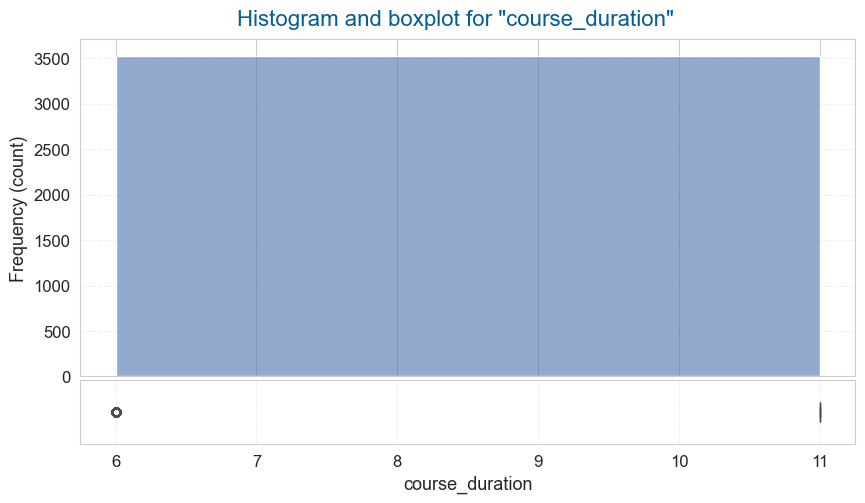

Descriptive statistics:


,0
Column name,course_duration
Dtype,Int64
Value count,3533
Missing (NaN),16284
Unique values,2
Min,6
Q1,11
Mean,10.20
Q2 Median,11.00
Q3,11


Whisker bounds and outliers:


,Left,Right
Outlier bounds,11.00,11.00
Outlier count,567.00,0.00
Outlier %,16.05,0.00



────────────────────────────────────────────────────────────
  months_of_study
────────────────────────────────────────────────────────────


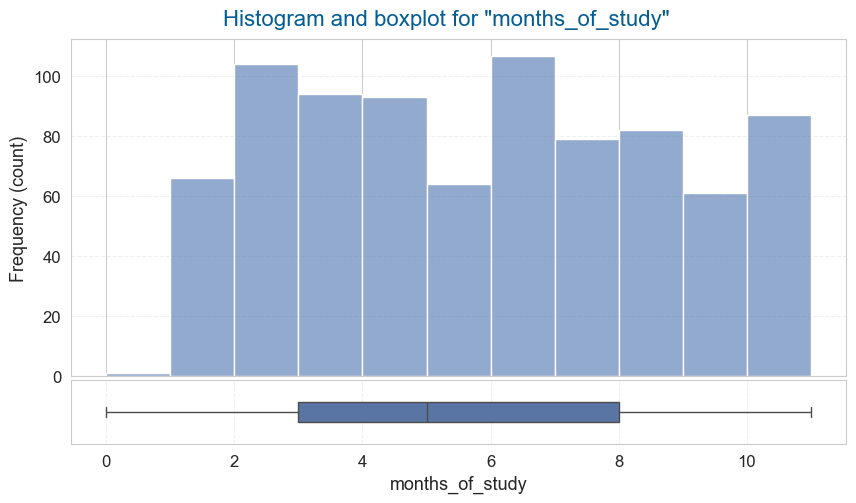

Descriptive statistics:


,0
Column name,months_of_study
Dtype,Int64
Value count,838
Missing (NaN),18979
Unique values,12
Min,0
Q1,3
Mean,5.45
Q2 Median,5.00
Q3,8


Whisker bounds and outliers:


,Left,Right
Outlier bounds,-4.50,15.50
Outlier count,0.00,0.00
Outlier %,0.00,0.00



────────────────────────────────────────────────────────────
  initial_amount_paid
────────────────────────────────────────────────────────────


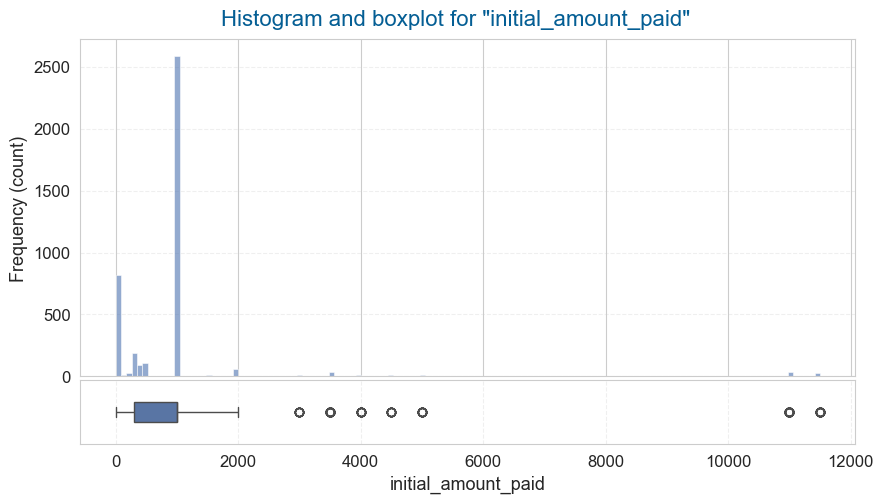

Descriptive statistics:


,0
Column name,initial_amount_paid
Dtype,float64
Value count,4060
Missing (NaN),15757
Unique values,23
Min,0.00
Q1,300.00
Mean,957.22
Q2 Median,1000.00
Q3,1000.00


Whisker bounds and outliers:


,Left,Right
Outlier bounds,-750.00,2050.00
Outlier count,0.00,144.00
Outlier %,0.00,3.55



────────────────────────────────────────────────────────────
  offer_total_amount
────────────────────────────────────────────────────────────


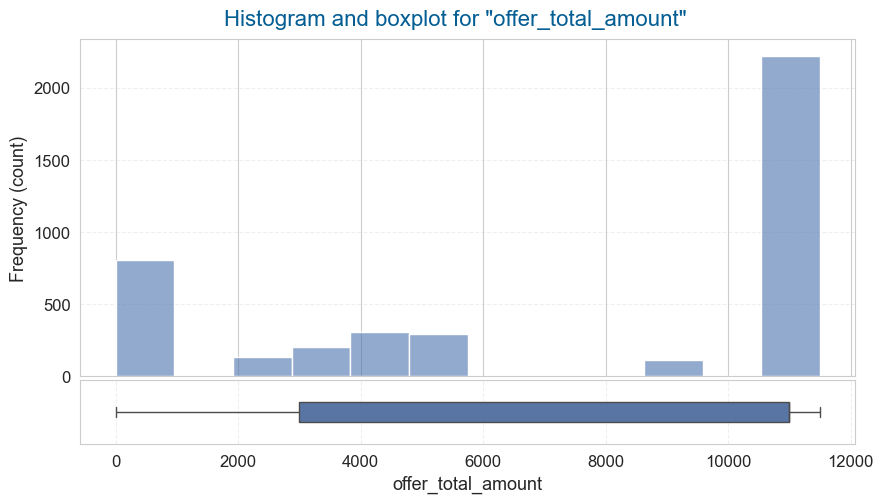

Descriptive statistics:


,0
Column name,offer_total_amount
Dtype,float64
Value count,4095
Missing (NaN),15722
Unique values,21
Min,0.00
Q1,3000.00
Mean,7183.32
Q2 Median,11000.00
Q3,11000.00


Whisker bounds and outliers:


,Left,Right
Outlier bounds,-9000.00,23000.00
Outlier count,0.00,0.00
Outlier %,0.00,0.00


In [107]:
for col in dataset_config['num_cols']:
    if col not in df.columns:
        print(f"Column {col} not found in the dataset, skipping")
        continue

    print(f"\n{'─'*60}")
    print(f"  {col}")
    print(f"{'─'*60}")

    # Histogram + boxplot
    h.hist_box(col, df, title=col)
    print('Descriptive statistics:')
    display(h.descr_df(df[[col]], show=False).T)

    # Table with quantiles and outlier bounds
    print('Whisker bounds and outliers:')
    h.iqr_outliers(col, df)

In [108]:
# Summary table for all columns 
h.descr_df(df, include=['number'], show_stats=False, show_sample_rows=True)

,Column name,Dtype,Value count,Missing (NaN),Unique values,Sample row 1,Sample row 2,Sample row 3
0,sla,timedelta64[ns],14995,4822,12944,NaT,NaT,0 days 00:26:43
1,course_duration,Int64,3533,16284,2,<NA>,6,<NA>
2,months_of_study,Int64,838,18979,12,<NA>,<NA>,<NA>
3,initial_amount_paid,float64,4060,15757,23,NaN,0.00,NaN
4,offer_total_amount,float64,4095,15722,21,NaN,2000.00,NaN


`course_duration`: 6-11 months (mode=11)
16K missing (82%)
IQR=0, outliers 16%
Data is uniform but almost empty   

`months_of_study`: 0-11 months (median 5)
18K missing (96%)
IQR=5, 0% recovered
Short courses dominate, data almost empty   

`initial_amount_paid`: €300-1000 (mode ~1000)
16K missing (79%)
IQR=700, outliers 3.6% (>€2050)
First payment is uniform, many missing values   

`offer_total_amount`: €3K-11K (mode 11K)
16K missing (79%)
IQR=8K, new 0%
Full price is bimodal, many missing values

### Handling 'initial_amount_paid', 'offer_total_amount'

In [109]:
print('Descriptive statistics:')
display(h.descr_df(df[['initial_amount_paid']], include=['number'], show=False))
display(h.descr_df(df[['offer_total_amount']], include=['number'], show=False))

Descriptive statistics:


,Column name,Dtype,Value count,Missing (NaN),Unique values,Min,Q1,Mean,Q2 Median,Q3,Max,Range,IQR
0,initial_amount_paid,float64,4060,15757,23,0.00,300.00,957.22,1000.00,1000.00,11500.00,11500.00,700.00


,Column name,Dtype,Value count,Missing (NaN),Unique values,Min,Q1,Mean,Q2 Median,Q3,Max,Range,IQR
0,offer_total_amount,float64,4095,15722,21,0.00,3000.00,7183.32,11000.00,11000.00,11500.00,11500.00,8000.00


In [110]:
# 'initial_amount_paid', 'offer_total_amount' - we already converted them to numeric earlier and cleaned the column format
cols = ['initial_amount_paid', 'offer_total_amount']
h.colls_stats(df, cols)

,Column name,Dtype,Value count,Missing (NaN),Missing %,Non-missing,Non-missing %,Unique
0,initial_amount_paid,float64,4060,15757,79.51,4060,20.49,23
1,offer_total_amount,float64,4095,15722,79.34,4095,20.66,21


(0, 1, 9) - demo access for a symbolic fee - they don't reflect the real picture and break the averages => look at the data without them

In [111]:
# Handle odd values (0, 1, 9) - demo access for a symbolic fee
cols = ['initial_amount_paid', 'offer_total_amount' ]
for col in cols:
    df[df[col] < 10].shape
    df.loc[df[col] < 10, col] = pd.NA
    # print(f"{col}: {df[col].unique()}\n")
    
    print('Descriptive statistics:')
    display(h.descr_df(df[[col]], include=['number'], show=False))

Descriptive statistics:


,Column name,Dtype,Value count,Missing (NaN),Unique values,Min,Q1,Mean,Q2 Median,Q3,Max,Range,IQR
0,initial_amount_paid,float64,3239,16578,20,100.00,1000.00,1199.85,1000.00,1000.00,11500.00,11400.00,0.00


Descriptive statistics:


,Column name,Dtype,Value count,Missing (NaN),Unique values,Min,Q1,Mean,Q2 Median,Q3,Max,Range,IQR
0,offer_total_amount,float64,3288,16529,19,1000.00,5000.00,8946.38,11000.00,11000.00,11500.00,10500.00,6000.00


Money values were stored as strings with currency symbols and various number formats. The data was cleaned and converted to a numeric type (handled in Section 6).    
Values under €10 were interpreted as test or demo payments and excluded from the analysis.   

1.`Analysis of initial_amount_paid (First payment)`:   
**Minimum 1000.00**: We got rid of the "noise" of €0 and €1. Now the minimum entry threshold for the school is 100 (webinars).   
**Typical ticket**: Median 1,000 with a maximum of 11,500. This confirms the business model: most customers don't pay the full amount up front, but make a registration fee or first payment of about 1,000.   
**Mean** 1199: It moved up (it was ~960). 
**Q1, Median and Q3** all equal 1000.00: => IQR became 0.00 => a completely standardized first-payment system. The overwhelming majority of customers 
**Anomalies**: The maximum in this column (11,500) matches the maximum full price. This means there are customers (few, though) who pay for the course in full in one payment (Full Pay) = outliers - 3.5%.  

2.`Analysis of 'offer_total_amount' (Full price):      
**Mean** 8946: It moved up (it was ~7k), which makes sense. But it is still below the median, because Q1 (5000) shows a segment of cheaper courses that "dilute" total revenue
**Median vs Mean**: The median (11,000) is significantly higher than the mean (8,946), which points to a "heavy tail" on the left. Many deals with small amounts (discounts, special offers, or short courses) "pull" the mean down, but the main product costs exactly 11,000.   
**Conclusion**: The company's main product costs 11,000-11,500 (visible from Q2, Q3 and Max).    
**Concentration**: Q1 is 5,000 and the median is 11,000. This means 75% of all deals with a stated price are above 5,000     
**IQR** 6,000: The wide spread between the 25th (5,000) and 75th (11,000) percentiles confirms the school has at least two product segments: "cheap" (intro courses/intensives and evening study) and "expensive" (full study - daytime).   
**Outliers** (0): The whisker bounds (-9000 to 23000) fully cover our data. This means there are no anomalies (entry errors) in the amounts. A maximum of 11,500 looks like a logical price ceiling.

### Handling 'SLA'

SLA is the sales rep's response time to an application, i.e. how much time passed from the lead submitting the application to a rep contacting them

In [112]:
display(h.descr_df(df[['sla']], show=False))

,Column name,Dtype,Value count,Missing (NaN),Unique values,Min,Q1,Mean,Q2 Median,Q3,Max,Range,IQR
0,sla,timedelta64[ns],14995,4822,12944,0 days 00:00:03,0 days 01:13:18,1 days 06:57:54.592464154,0 days 05:29:51,0 days 15:32:06,311 days 10:34:24,311 days 10:34:21,0 days 14:18:48


In [113]:
# Table with quantiles and outlier bounds
print('Whisker bounds and outliers:')
h.iqr_outliers('sla', df)

Whisker bounds and outliers:


,Left,Right
Outlier bounds,-1 days +03:45:06,1 days 13:00:18
Outlier count,0,1331
Outlier %,0.00,8.88


`SLA is the sales rep's response time to an application`:   

**Median (Q2)** - 5 hours 29 minutes: Half of all processes (deals/responses) fit within 5.5 hours.   
**Mean** - 1 day 7 hours:   
The mean is almost 5 times the median. This is a classic sign of a "long tail" - a small number of deals "hung" for a very long time and pulled the average up.  
**Maximum** - 311 days:   
Some deals stayed open for almost a year. That is clearly either a system error or "forgotten" customers.   
**Minimum** - 3 seconds:   
Very fast triggers. Probably either automatic rejections or instant moves of the deal to the next stage.  

`Outlier analysis`
**IQR (interquartile range)** is about 14 hours.   
**Lower bound (Q1)**: ~1 hour 13 minutes.   
**Upper bound (Q3)**: ~15 hours 32 minutes.   

**Business conclusion**: The bulk of the work (75% of the data) happens within 15.5 hours. Anything lasting longer than a day and a half (Q3 + 1.5*IQR) is formally an outlier for this sample (8.9%).

In [114]:
# Handle outliers - fill in based on the decisions from the table above

# Example: remove right-side outliers
# col = 'sla'
# outliers = h.iqr_outliers(col, df, show=False)
# right_border = outliers.loc['Outlier bounds', 'Right']
# df = df[df[col] <= right_border].copy()
# print(f"After removing right-side outliers in {col}: {df.shape}")

# Example: remove left-side outliers
# col = 'initial_amount_paid'
# outliers = h.iqr_outliers(col, df, show=False)
# left_border = outliers.loc['Outlier bounds', 'Left']
# df = df[df[col] >= left_border].copy()

print(f"Dataset size after outlier handling: {df.shape}")

Dataset size after outlier handling: (19817, 26)


**Observations and decisions:**   
'initial_amount_paid', 'offer_total_amount': Money values were stored as strings with currency symbols and various number formats. The data was cleaned and converted to a numeric type (handled in Section 6).   
Values under €10 were interpreted as test or demo payments and excluded from the analysis.

---
## 10. Univariate Analysis - Categorical Variables

For each categorical variable:
- frequency table with shares
- horizontal bar plot


────────────────────────────────────────────────────────────
  deal_owner_name  (28 unique values)
────────────────────────────────────────────────────────────


,deal_owner_name,count,%
0,Charlie Davis,2464,12.40
1,Ulysses Adams,2096,10.60
2,Julia Nelson,2012,10.20
3,Paula Underwood,1618,8.20
4,Quincy Vincent,1574,7.90
5,Nina Scott,1300,6.60
6,Ben Hall,1116,5.60
7,Victor Barnes,1077,5.40
8,Cara Iverson,925,4.70
9,Diana Evans,811,4.10


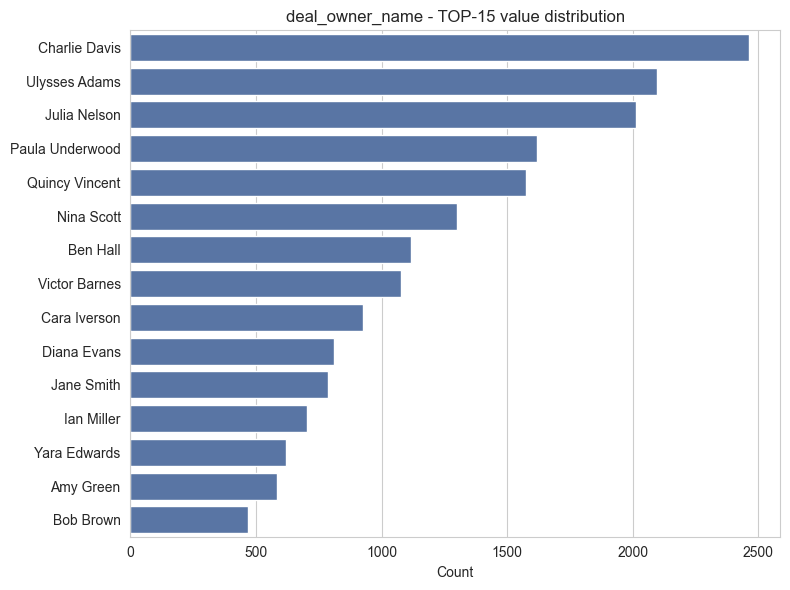


────────────────────────────────────────────────────────────
  quality  (5 unique values)
────────────────────────────────────────────────────────────


,quality,count,%
0,E - Non Qualified,6144,34.90
1,D - Non Target,6078,34.60
2,C - Low,3403,19.40
3,B - Medium,1543,8.80
4,A - High,418,2.40
5,F,0,0.00
6,Unknown,0,0.00


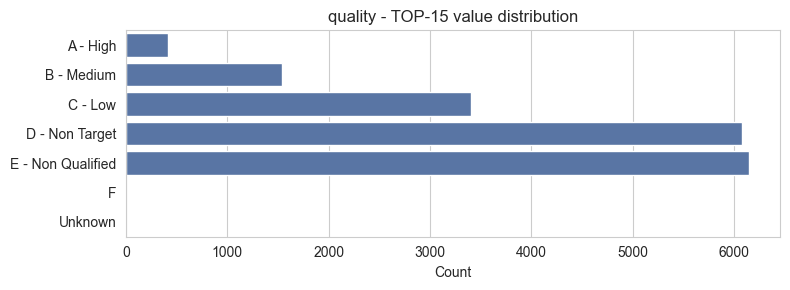


────────────────────────────────────────────────────────────
  stage  (13 unique values)
────────────────────────────────────────────────────────────


,stage,count,%
0,Lost,13997,70.60
1,Call Delayed,2243,11.30
2,Registered on Webinar,2066,10.40
3,Payment Done,856,4.30
4,Waiting For Payment,324,1.60
5,Qualificated,128,0.60
6,Registered on Offline Day,85,0.40
7,Need to Call - Sales,33,0.20
8,Need To Call,31,0.20
9,Test Sent,25,0.10


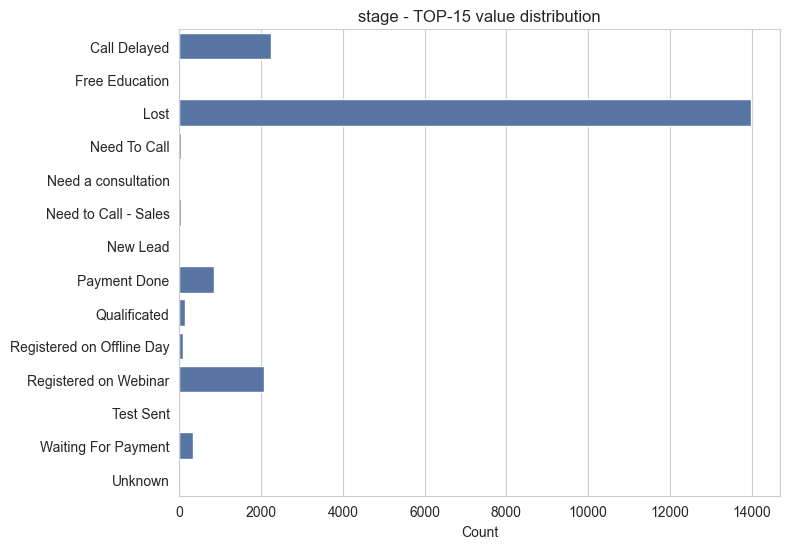


────────────────────────────────────────────────────────────
  lost_reason  (20 unique values)
────────────────────────────────────────────────────────────


,lost_reason,count,%
0,Doesn't Answer,4135,28.80
1,Changed Decision,2146,15.00
2,Non target,1761,12.30
3,Stopped Answering,1588,11.10
4,Invalid number,1481,10.30
5,needs time to think,655,4.60
6,Expensive,626,4.40
7,Conditions are not suitable,531,3.70
8,Next stream,288,2.00
9,Inadequate,176,1.20


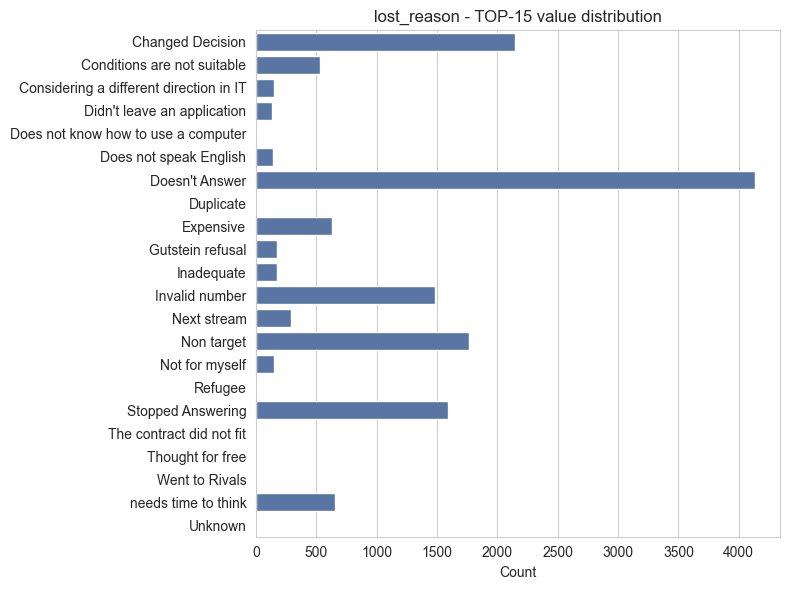


────────────────────────────────────────────────────────────
  page  (33 unique values)
────────────────────────────────────────────────────────────


,page,count,%
0,/eng,5682,28.70
1,eng/digital-marketing,4371,22.10
2,/eng/test,2765,14.00
3,/webinar,1114,5.60
4,/workshop,1055,5.30
5,/direct,1040,5.20
6,/eng/ux-ui,1020,5.10
7,/web-developer,638,3.20
8,/pl-eng,439,2.20
9,/email,396,2.00


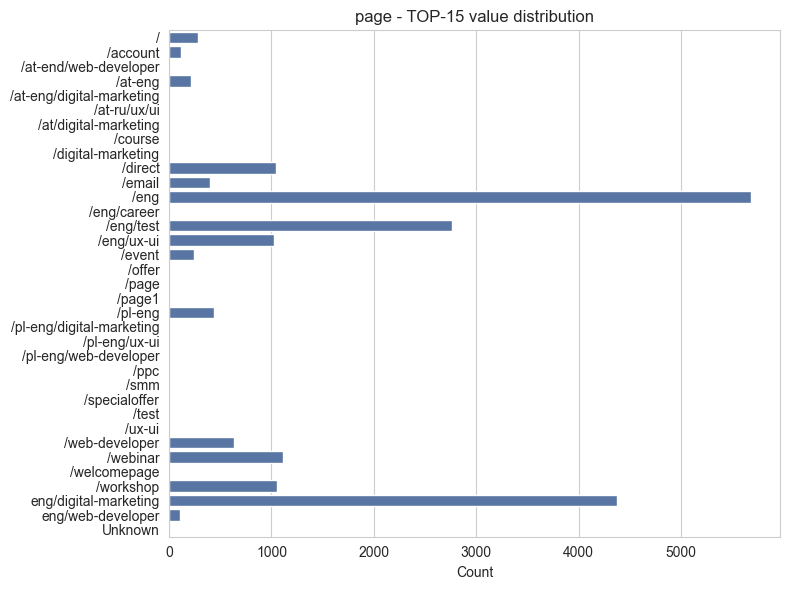


────────────────────────────────────────────────────────────
  ad  (163 unique values)
────────────────────────────────────────────────────────────


,ad,count,%
0,(no ad),9564,48.30
1,bloggersvideo9com,1502,7.60
2,bloggersvideo4com,795,4.00
3,bloggersvideo5,754,3.80
4,bloggersvideo14com,583,2.90
...,...,...,...
158,v8com,1,0.00
159,ad5,1,0.00
160,157624907008_{region_name}_668024583827,1,0.00
161,ad3,1,0.00


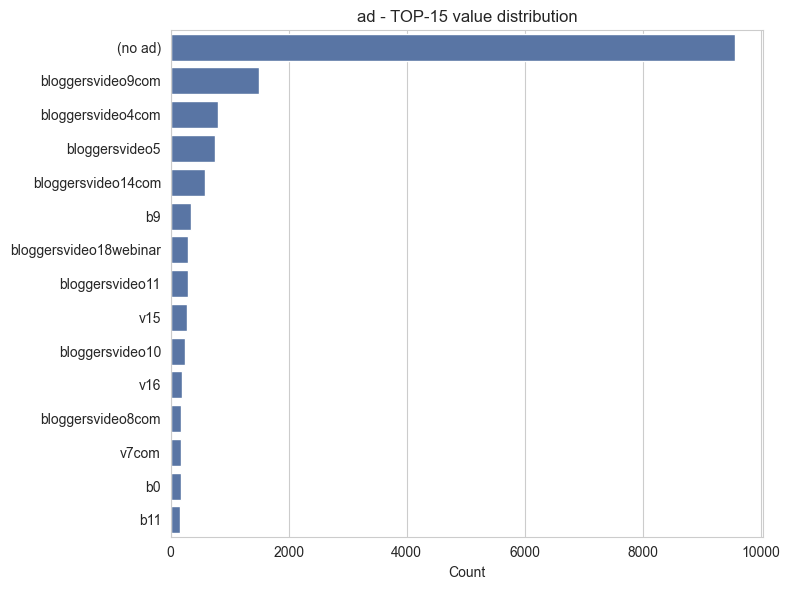

Column content not found, skipping

────────────────────────────────────────────────────────────
  ad_group  (193 unique values)
────────────────────────────────────────────────────────────


,ad_group,count,%
0,(no ad_group),5049,25.50
1,_,3416,17.20
2,wide,3379,17.10
3,Com_august,1487,7.50
4,recentlymoved,733,3.70
...,...,...,...
188,qual_Com_3_days,1,0.00
189,07_08_2023,1,0.00
190,01_09_2023,1,0.00
191,geekbrains,1,0.00


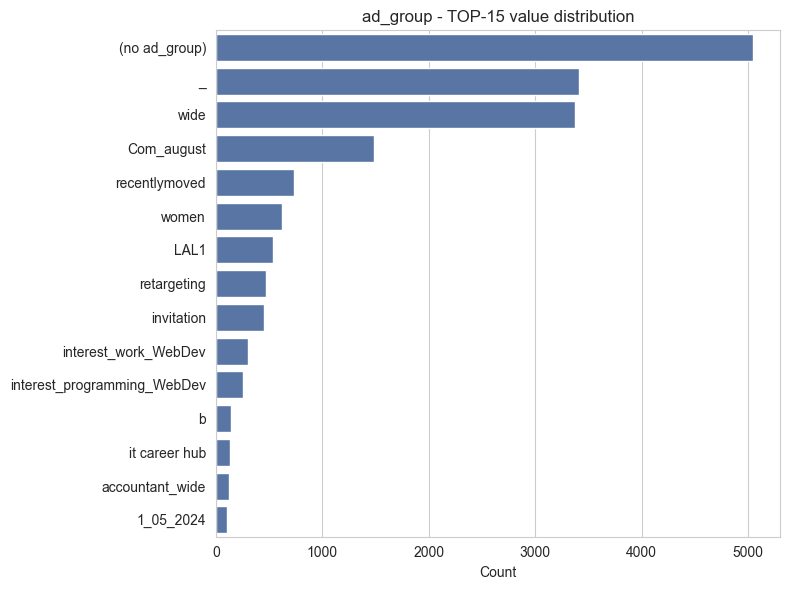


────────────────────────────────────────────────────────────
  source  (13 unique values)
────────────────────────────────────────────────────────────


,source,count,%
0,Facebook Ads,4729,23.90
1,Google Ads,4114,20.80
2,Tiktok Ads,2003,10.10
3,SMM,1669,8.40
4,Youtube Ads,1618,8.20
5,Organic,1498,7.60
6,CRM,1455,7.30
7,Bloggers,1074,5.40
8,Telegram posts,993,5.00
9,Webinar,305,1.50


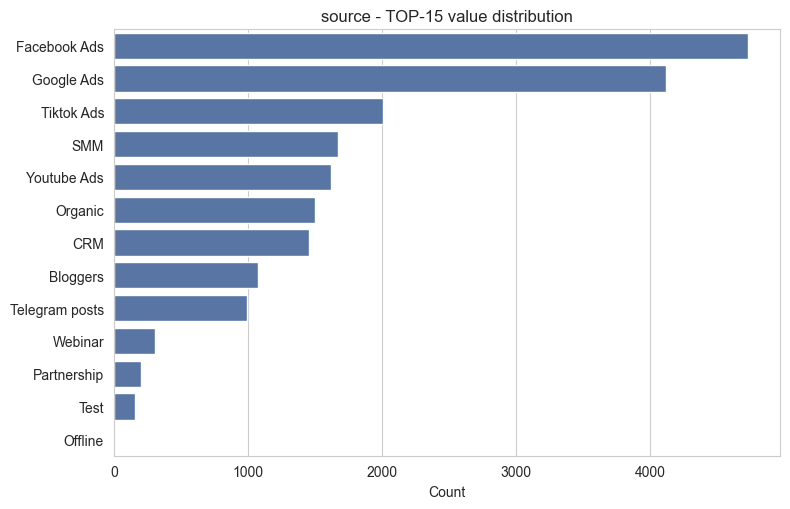


────────────────────────────────────────────────────────────
  payment_type  (4 unique values)
────────────────────────────────────────────────────────────


,payment_type,count,%
0,Unknown,15856,80.00
1,One Payment,2726,13.80
2,Recurring Payments,1230,6.20
3,Reservation,5,0.00


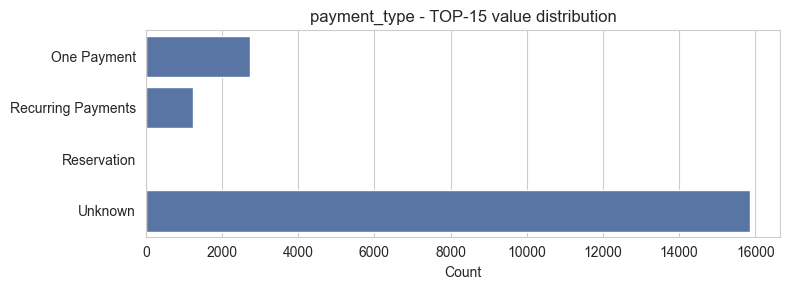


────────────────────────────────────────────────────────────
  product  (6 unique values)
────────────────────────────────────────────────────────────


,product,count,%
0,Unknown,16280,82.20
1,Digital Marketing,1953,9.90
2,UX/UI Design,1013,5.10
3,Web Developer,567,2.90
4,Find yourself in IT,3,0.00
5,Data Analytics,1,0.00


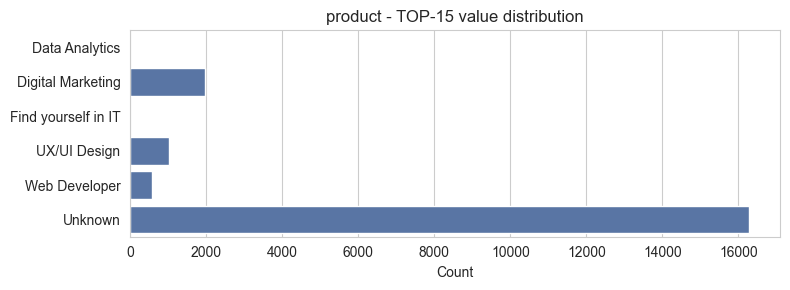


────────────────────────────────────────────────────────────
  education_type  (3 unique values)
────────────────────────────────────────────────────────────


,education_type,count,%
0,Unknown,15651,79.00
1,Morning,2989,15.10
2,Evening,1177,5.90


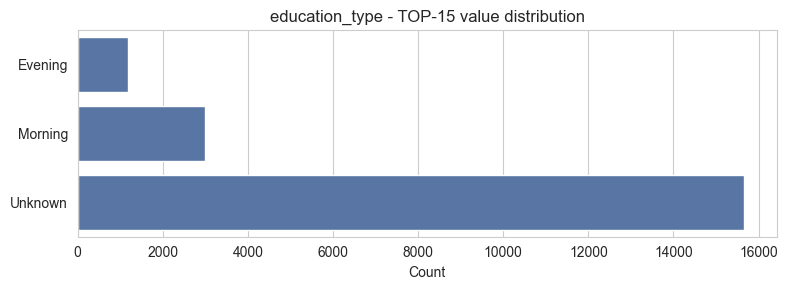


────────────────────────────────────────────────────────────
  city  (876 unique values)
────────────────────────────────────────────────────────────


,city,count,%
0,Unknown,17110,86.30
1,Berlin,264,1.30
2,München,88,0.40
3,Hamburg,78,0.40
4,Nürnberg,54,0.30
...,...,...,...
871,Günzburg,1,0.00
872,Malschwitz,1,0.00
873,Blankenburg,1,0.00
874,Eschenburg,1,0.00


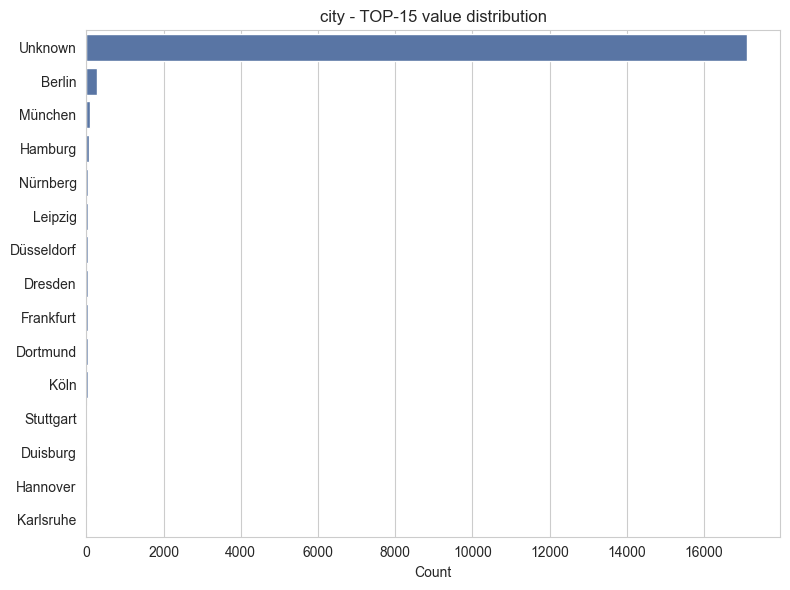


────────────────────────────────────────────────────────────
  level_of_deutsch  (8 unique values)
────────────────────────────────────────────────────────────


,level_of_deutsch,count,%
0,Unclear,18296,92.30
1,B1,1032,5.20
2,B2,210,1.10
3,A2,205,1.00
4,C1,35,0.20
5,A1,28,0.10
6,A0,7,0.00
7,C2,4,0.00


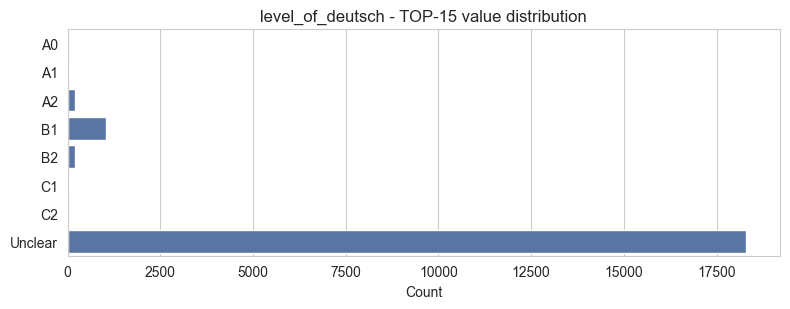

In [115]:
plt_to_save_png = ['deal_owner_name', 'source']  # Specify which variable's chart to save

for col in dataset_config['cat_cols']:
    if col not in df.columns:
        print(f"Column {col} not found, skipping")
        continue

    print(f"\n{'─'*60}")
    print(f"  {col}  ({df[col].nunique()} unique values)")
    print(f"{'─'*60}")

    # Frequency table
    freq = df[col].value_counts().reset_index()
    freq.columns = [col, 'count']
    freq = freq.sort_values(by='count', ascending=False)
    freq['%'] = (freq['count'] / freq['count'].sum() * 100).round(1)
    display(freq)

    # Bar plot (top 15 values if more)
    top_vals = freq.sort_values(by='count', ascending=False).head(15)

    plt.figure(figsize=(8, max(3, len(top_vals) * 0.4)))
    sns.barplot(data=top_vals, y=col, x='count', orient='h')
    plt.title(f"{col} - TOP-15 value distribution")
    plt.xlabel("Count")
    plt.ylabel("")
    plt.tight_layout()
    if col in plt_to_save_png:
        plt.savefig(IMAGES / f"{dataset_config['name']}_{col}_barplot.png",
                    dpi=150, bbox_inches='tight')
    plt.show()

In [116]:
# Quality: E/D (70%) >> C/B/A (28%) >> F=0%
# 'F' - accidental entry, replace with 'Unknown'
df['quality'] = df['quality'].replace('F', 'Unknown')
print(df['quality'].value_counts())

quality
E - Non Qualified    6144
D - Non Target       6078
C - Low              3403
B - Medium           1543
A - High              418
Unknown                 0
Name: count, dtype: int64


C:\Users\user\AppData\Local\Temp\ipykernel_2352\3446989679.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['quality'] = df['quality'].replace('F', 'Unknown')


In [117]:
# Group the stages from 'stage'
def simplify_stage(df):
    """Simplify stage"""
    conditions = [
        (df['stage'] == 'Lost'),                                    # 0. Lost
        (df['stage'] == 'Payment Done'),                            # 1. Payment Done  
        (df['stage'].isin(['Call Delayed', 'Need to Call - Sales', 'Need To Call', 'Need a consultation'])),  # 2. In progress
        (df['stage'].isin(['Registered on Webinar', 'Registered on Offline Day', 'Qualificated', 'Test Sent'])), # 3. Registrations
        (df['stage'].isin(['Waiting For Payment', 'New Lead', 'Free Education']))  # 4. Waiting for payment
    ]
    choices = ['Lost', 'Payment Done', 'In Progress', 'Registrations', 'Waiting For Payment']
    
    df['stage_simplified'] = np.select(conditions, choices, default='Other')
    return df

# Apply:
df = simplify_stage(df)
print(df['stage_simplified'].value_counts())

stage_simplified
Lost                   13997
In Progress             2330
Registrations           2304
Payment Done             856
Waiting For Payment      330
Name: count, dtype: int64


In [118]:
# Check the previously created deal flag = 'Payment Done'
print(pd.crosstab(df['stage_simplified'], df['is_paid']))

is_paid              False  True 
stage_simplified                 
In Progress           2330      0
Lost                 13997      0
Payment Done             0    856
Registrations         2304      0
Waiting For Payment    330      0


In [119]:
# Restore the category type
df['stage_simplified'] = df['stage_simplified'].astype('category')

**Observations and changes:** 

1) For 'Product', about 82% of records don't even record what the lead was interested in.   
2) Created a 'stage_simplified' dictionary to combine similar or rare stages into broader ones.

---
## 11. Univariate Analysis - Date Columns

For each date column:
- range and basic statistics
- monthly distribution (time series)


────────────────────────────────────────────────────────────
  closing_date
────────────────────────────────────────────────────────────
  Min:  2022-10-11 00:00:00
  Max: 2024-12-11 00:00:00
  Missing: 6681


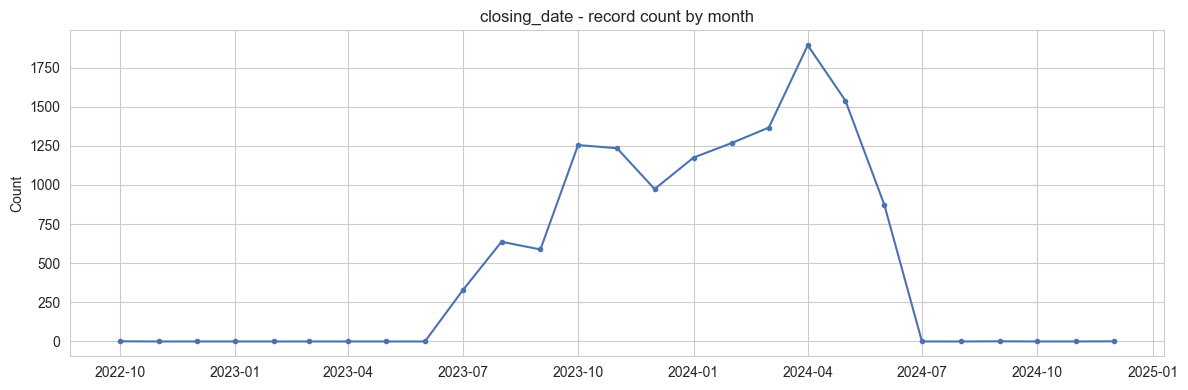


────────────────────────────────────────────────────────────
  created_time
────────────────────────────────────────────────────────────
  Min:  2023-07-03 17:03:00
  Max: 2024-06-21 15:30:00
  Missing: 0


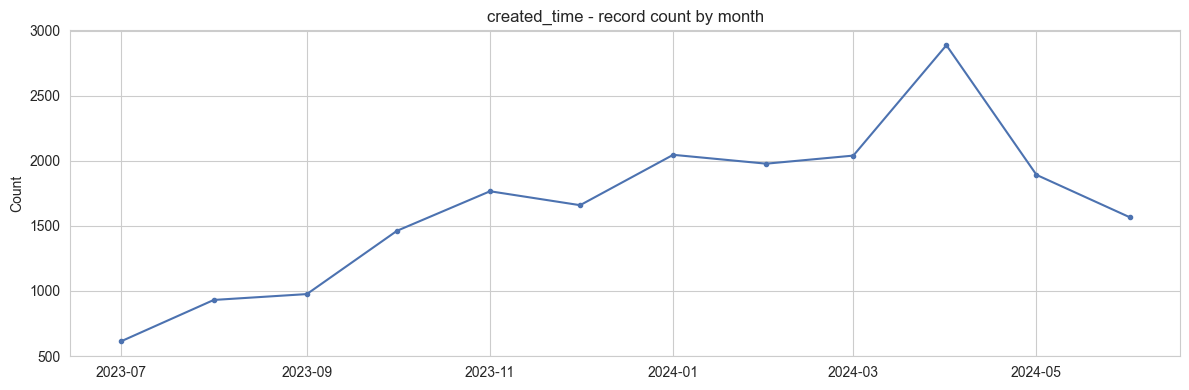

In [120]:
for col in dataset_config['date_cols']:
    if col not in df.columns:
        print(f"Column {col} not found, skipping")
        continue

    print(f"\n{'─'*60}")
    print(f"  {col}")
    print(f"{'─'*60}")

    # Basic statistics
    print(f"  Min:  {df[col].min()}")
    print(f"  Max: {df[col].max()}")
    print(f"  Missing: {df[col].isnull().sum()}")

    # Monthly time series
    monthly = df.set_index(col).resample('MS').size()

    plt.figure(figsize=(12, 4))
    plt.plot(monthly.index, monthly.values, marker='o', markersize=3, linewidth=1.5)
    plt.title(f"{col} - record count by month")
    plt.ylabel("Count")
    plt.xlabel("")
    plt.tight_layout()
    # plt.savefig(IMAGES / f"{dataset_config['name']}_{col}_timeseries.png",
    #             dpi=150, bbox_inches='tight')
    plt.show()

'closing_date' has an anomalous period from ... to   
* 2022 data – outside the period (before 2023-06)
* 11 December 2024 - in the future (after 21 June 2024)

In [121]:
# Call the colls_stats function
cols = ['created_time', 'closing_date']
h.colls_stats(df, cols)

,Column name,Dtype,Value count,Missing (NaN),Missing %,Non-missing,Non-missing %,Unique
0,created_time,datetime64[ns],19817,0,0.00,19817,100.00,18785
1,closing_date,datetime64[ns],13136,6681,33.71,13136,66.29,357


---
##### Datasets 'contacts_cleaned.pkl' and 'calls_cleaned.pkl'

Checking deal-date correctness: a deal created before the contact or call.

In [122]:
# 'contacts_cleaned.pkl'
contacts.head(3)

,contact_id,contact_owner_name,created_time,modified_time,created_date,key
0,5805028000000645014,Rachel White,2023-06-27 11:28:00,2023-12-22 13:34:00,2023-06-27,5805028000000645014_2023-06-27 11:28:00
1,5805028000000872003,Charlie Davis,2023-07-03 11:31:00,2024-05-21 10:23:00,2023-07-03,5805028000000872003_2023-07-03 11:31:00
2,5805028000000889001,Bob Brown,2023-07-02 22:37:00,2023-12-21 13:17:00,2023-07-02,5805028000000889001_2023-07-02 22:37:00


In [123]:
# 'calls_cleaned.pkl'
colls = ['calls_id', 'call_start_time', 'contact_id', 'call_start_date']
calls[colls].head(3)

,calls_id,call_start_time,contact_id,call_start_date
0,5805028000000805001,2023-06-30 08:43:00,Unknown,2023-06-30
1,5805028000000768006,2023-06-30 08:46:00,Unknown,2023-06-30
2,5805028000000764027,2023-06-30 08:59:00,Unknown,2023-06-30


---

#### (Deals vs Contacts) / 'created_date_deals' < 'created_date_contact'

In [124]:
# If the Deals creation date is earlier than in Contacts, replace created_time in deals with the date from contacts.
# Print the minimum deal time for each deals_id

deals_contacts = df[['deals_id', 'contact_id', 'is_paid', 'created_time']].merge(
    contacts[['contact_id', 'created_time']], 
    on='contact_id', suffixes=('_deals', '_contact')
)

deals_contacts['delta'] = deals_contacts['created_time_deals'] - deals_contacts['created_time_contact']
deals_contacts.sort_values(by='delta', ascending=False)

# Deals 'created_date' vs Contacts 'created_date'  
mask_wrong = deals_contacts['created_time_deals'] < deals_contacts['created_time_contact']
print(f"Deals 'created_date' earlier than Contact: {mask_wrong.sum()}")

Deals 'created_date' earlier than Contact: 23


In [125]:
# Use the suffixed names created by the merge
bad_ids = deals_contacts.loc[
    deals_contacts['created_time_deals'] < deals_contacts['created_time_contact'], 
    'deals_id'
]

# Build a time-mapping so we don't lose precision - by time
contact_time_map = contacts.set_index('contact_id')['created_time']

# 1. Replace the time in Deals with the time from Contacts
df.loc[df['deals_id'].isin(bad_ids), 'created_time'] = df.loc[df['deals_id'].isin(bad_ids), 'contact_id'].map(contact_time_map)

# 2. Sync the date (recompute it from the corrected time)
df['created_date'] = pd.to_datetime(df['created_time'].dt.date, format='%d.%m.%Y')

print(f"Deals fixed that were created before the contact: {len(bad_ids)}")

Deals fixed that were created before the contact: 23


#### (Deals) / 'closing_date' < 'created_date'

In [126]:
# 1. Find problem rows within deals, where 'closing_date' < 'created_date' - anomaly: closing earlier than creation
# Since closing_date has no time stamp, compare only so the day isn't days earlier
mask_internal = df['closing_date'] < df['created_date']
bad_internal = df[mask_internal][['deals_id', 'contact_id', 'is_paid', 'created_time', 'created_date', 'closing_date']].copy()
bad_internal['delta'] = bad_internal['closing_date'] - bad_internal['created_date']

print(f"\n'closing_date' < 'created_date': {mask_internal.sum()} records ({mask_internal.mean()*100:.2f}%)")
display(bad_internal.head(38).sort_values('delta'))


'closing_date' < 'created_date': 41 records (0.21%)


,deals_id,contact_id,is_paid,created_time,created_date,closing_date,delta
4519,5805028000045245616,5805028000003597256,False,2024-04-20 06:19:00,2024-04-20,2023-08-21,-243 days
6356,5805028000042015392,5805028000009072093,True,2024-04-05 10:40:00,2024-04-05,2023-10-03,-185 days
14005,5805028000022036007,<NA>,True,2023-12-19 10:37:00,2023-12-19,2023-07-01,-171 days
13891,5805028000022357441,5805028000044640003,True,2024-04-17 13:58:00,2024-04-17,2024-02-23,-54 days
17644,5805028000013174103,5805028000013128091,False,2023-10-21 21:17:00,2023-10-21,2023-09-26,-25 days
18271,5805028000010744206,5805028000010764225,False,2023-10-10 16:21:00,2023-10-10,2023-09-20,-20 days
18163,5805028000011322126,5805028000011144141,False,2023-10-12 18:17:00,2023-10-12,2023-09-26,-16 days
3725,5805028000047355242,5805028000050513155,True,2024-05-17 13:02:00,2024-05-17,2024-05-02,-15 days
18520,5805028000010216149,5805028000010209081,False,2023-10-05 19:02:00,2023-10-05,2023-09-24,-11 days
10544,5805028000030630156,5805028000030637199,False,2024-02-07 17:39:00,2024-02-07,2024-01-31,-7 days


In [127]:
# Set the closing date equal to the creation date
# fix only the problem rows, overwriting them so 'created_date' <= 'closing_date'
df.loc[mask_internal, 'closing_date'] = df.loc[mask_internal, 'created_date']
# Check:
print(f"Problem rows remaining: {(df['closing_date'] < df['created_date']).sum()}")

Problem rows remaining: 0


#### (Deals vs Call) / 'call_start_time' vs 'created_date'

In [128]:
# Calls 'call_start_time' vs Deals 'created_date'
calls_min = calls.groupby('contact_id')['call_start_date'].min().reset_index()

deals_calls = df.merge(
    calls_min[['contact_id', 'call_start_date']],
    on='contact_id',
    how='left'
)

mask_calls = deals_calls['created_date'] < deals_calls['call_start_date']
print(f"Deal earlier than the first call: {mask_calls.sum()}")

Deal earlier than the first call: 5580


In [129]:
# with completed deals
mask = deals_calls['is_paid'] == True
calls_min[mask]

C:\Users\user\AppData\Local\Temp\ipykernel_2352\961645666.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  calls_min[mask]


,contact_id,call_start_date
441,5805028000003286114,2023-07-28
450,5805028000003298106,2023-07-28
466,5805028000003415542,2023-08-03
785,5805028000004323103,2023-08-09
985,5805028000005153065,2023-08-19
...,...,...
15131,5805028000056314198,2024-06-19
15140,5805028000056357143,2024-06-19
15164,5805028000056567056,2024-06-20
15186,5805028000056704198,2024-06-20


In [130]:
# Compute the difference between payment/closing and the call

# Anomaly: payment happened before the first call
anomaly_paid = deals_calls[
    (deals_calls['is_paid'] == True) & 
    (deals_calls['closing_date'] < deals_calls['call_start_date'].dt.date)
]

print(f"Paid before the first call: {len(anomaly_paid)} deals")

# Anomaly: deal closed (any final status) before the first call
anomaly_closed = deals_calls[
    (deals_calls['closing_date'] < deals_calls['call_start_date'].dt.date)
]

print(f"Closed before the first call: {len(anomaly_closed)} deals")

Paid before the first call: 4 deals
Closed before the first call: 305 deals


**Date observations:**

1) The time interval doesn't match the created_time dates at its boundaries. This points to a lack of setup in the CRM system - the absence of system add-ons that would close out stuck, unprocessed deals once the allowed overdue period is exceeded, or reminders to managers about unprocessed applications hanging in the system. 33.7% of closing dates are missing. It may also signal that, if such settings or stuck-deal reporting exist in the CRM, managers ignore them and do a poor job of filling in statuses.   

closing_date
────────────────────────   
  Min:  2022-10-11   
  Max: 2024-12-11     

Next, possible technical inaccuracies of the system were checked by linking the time data of this dataset with the Contacts and Calls datasets in different ways. A logical chain for restoring real events was applied so as not to distort the statistics for further analysis. Unclosed dates with a long tail were left uncorrected, since they are unrecoverable - there is no real understanding of the date the deal was lost.  

* Isolated cases were found where the deal closing date is earlier than the contact creation date (~0.1%).   
The errors were fixed by setting 'closing_date' to 'created_date'.   
* Within the dataset (Deals) / 'closing_date' < 'created_date', 41 records (0.21%) were found and fixed.   
* The relationship between calls and deals was not rigidly enforced, since the business process allows various scenarios.   
The time sequence between calls and deals can vary, because calls can happen both before and after a deal is created.   
No fixes were made (cases found (~28%) where the deal was created before the first call).     
In the CRM, these scenarios are possible:      
- No call (customer left an application -> deal immediately = 4 deals out of 616 marked as paid). That is 0.02% of the whole dataset. These could be:   
Test payments by employees themselves.   
Loyal customers ("self-starters") who bought straight from an ad link.   
Verdict: Ignore as statistical noise.      
- Deal before the call (manager created the deal -> then called = 305 of 616 marked as paid)
- The "Closed" lead quality also includes the Lost stage (rejection). These are leads that managers closed "into the bin" with no call at all. Reasons: no answer, wrong number, spam applications, or duplicates.  Verdict: This is an important marketing-quality indicator (junk leads).

---
## 12. Univariate Analysis - Boolean Variables

For boolean variables, look at the True / False ratio.

In [131]:
for col in dataset_config['bool_cols']:
    if col not in df.columns:
        print(f"Column {col} not found, skipping")
        continue

    print(f"\n{'─'*60}")
    print(f"  {col}")
    print(f"{'─'*60}")

    # Frequency table
    freq = df[col].value_counts().reset_index()
    freq.columns = [col, 'count']
    freq['%'] = (freq['count'] / freq['count'].sum() * 100).round(1)
    display(freq)

    # Pie chart
    plt.figure(figsize=(5, 5))
    plt.pie(freq['count'], labels=freq[col].astype(str),
            autopct='%1.1f%%', startangle=90)
    plt.title(f"{col}")
    plt.tight_layout()
    # plt.savefig(IMAGES / f"{dataset_config['name']}_{col}_pie.png",
    #             dpi=150, bbox_inches='tight')
    plt.show()

There are no Boolean columns

---
## 13. Saving

Save the cleaned dataset to `data/processed/` as parquet.  
If a file with that name already exists, it's moved to `data/processed/backup/` with a timestamp.  
The config is updated in `data/processed/`.

In [132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19817 entries, 0 to 21583
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype          
---  ------               --------------  -----          
 0   deals_id             19817 non-null  string         
 1   deal_owner_name      19816 non-null  object         
 2   closing_date         13136 non-null  datetime64[ns] 
 3   quality              17586 non-null  category       
 4   stage                19817 non-null  category       
 5   lost_reason          14353 non-null  category       
 6   page                 19817 non-null  category       
 7   campaign             19817 non-null  object         
 8   sla                  14995 non-null  timedelta64[ns]
 9   ad                   19817 non-null  object         
 10  ad_group             19817 non-null  object         
 11  source               19817 non-null  object         
 12  payment_type         19817 non-null  category       
 13  product              

In [133]:
# Save the updated dataset to xlsx
sufix = 'cleaned'

dataset_path = PROCESSED / f"{dataset_config['name']}_{sufix}.xlsx"

# If the file already exists - back it up before overwriting
if dataset_path.exists():
    timestamp = datetime.now().strftime('%Y%m%d_%H%M')
    backup_path = BACKUP / f"{dataset_config['name']}_{sufix}_{timestamp}.xlsx"
    dataset_path.rename(backup_path)
    print(f"Previous file -> backed up as: {backup_path.name}")

# Save the cleaned dataset
df.to_excel(dataset_path, index=False)
print(f"Dataset saved:  {dataset_path.relative_to(PROJECT_ROOT)}")
print(f"Size:            {df.shape[0]:_} rows × {df.shape[1]} columns")

Dataset saved:  data\processed\deals_cleaned.xlsx
Size:            19_817 rows × 27 columns


In [134]:
# Save the updated CONFIG to pkl
sufix = 'config'
config_path = PROCESSED /  f"{sufix}_{dataset_config['name']}.pkl"

with open(config_path, "wb") as f:
    pickle.dump(dataset_config, f)
print(f"Config saved: {config_path.relative_to(PROJECT_ROOT)}")

# Save the updated DATASET to pkl
dataset_path = PROCESSED / f"{dataset_config['name']}_cleaned.pkl"    
df.to_pickle(dataset_path)

print(f"Dataset saved: {dataset_path.relative_to(PROJECT_ROOT)}")
print(f"Size: {df.shape[0]:_} × {df.shape[1]}")
print(f"{'─'*60}")
print(f"ID types: { {col: df[col].dtype for col in id_cols if col in df} }")

Config saved: data\processed\config_deals.pkl
Dataset saved: data\processed\deals_cleaned.pkl
Size: 19_817 × 27
────────────────────────────────────────────────────────────
ID types: {'deals_id': string[python], 'contact_id': string[python]}


In [135]:
# Check that everything was saved
print("Contents of the processed/ folder:")
for f in sorted(PROCESSED.glob('*')):
    if f.is_file():
        size_kb = f.stat().st_size / 1024
        print(f"  {f.name}  ({size_kb:.1f} KB)")

print()
print("Contents of the backup/ folder:")
for f in sorted(BACKUP.glob('*')):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name}  ({size_kb:.1f} KB)")

Contents of the processed/ folder:
  calls_cleaned.pkl  (6768.8 KB)
  calls_cleaned.xlsx  (4887.0 KB)
  config_calls.pkl  (0.3 KB)
  config_contacts.pkl  (0.3 KB)
  config_deals.pkl  (0.5 KB)
  contacts_cleaned.pkl  (871.5 KB)
  contacts_cleaned.xlsx  (568.0 KB)
  deals_cleaned.pkl  (3431.9 KB)
  deals_cleaned.xlsx  (2579.8 KB)

Contents of the backup/ folder:
  calls_cleaned_20261005_0841.xlsx  (4887.0 KB)
  contacts_cleaned_20261005_0843.xlsx  (568.0 KB)


---
## 14. Final Descriptive Statistics

In [136]:
# Can be loaded from PROCESSED to confirm everything was saved correctly 
# dataset_path

In [137]:
# Load the dataset by filename

dataset_path = PROCESSED / dataset_config['data_pkl']

# Load the cleaned dataset
df = pd.read_pickle(dataset_path)

# Print info about the load result
print(f"Loaded dataset: {dataset_path.relative_to(PROJECT_ROOT)}")
print(f"Type: {type(df)} ")
print("=" * 80)
# Original dataset size:
print(df_size_prev)
df_size_old = (f"Dataset size after processing:   {df.shape[0]:_} rows × {df.shape[1]} columns")
print(df_size_old)

print("=" * 80)
df.info()
print("Checking the saved ID types:")
print(df[['deals_id', 'contact_id']].dtypes)

Loaded dataset: data\processed\deals_cleaned.pkl
Type: <class 'pandas.core.frame.DataFrame'> 
Original dataset size:   21_595 rows × 23 columns
Dataset size after processing:   19_817 rows × 27 columns
<class 'pandas.core.frame.DataFrame'>
Index: 19817 entries, 0 to 21583
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype          
---  ------               --------------  -----          
 0   deals_id             19817 non-null  string         
 1   deal_owner_name      19816 non-null  object         
 2   closing_date         13136 non-null  datetime64[ns] 
 3   quality              17586 non-null  category       
 4   stage                19817 non-null  category       
 5   lost_reason          14353 non-null  category       
 6   page                 19817 non-null  category       
 7   campaign             19817 non-null  object         
 8   sla                  14995 non-null  timedelta64[ns]
 9   ad                   19817 non-null  object        

In [138]:
df.describe(include='all')

,deals_id,deal_owner_name,closing_date,quality,stage,lost_reason,page,campaign,sla,ad,ad_group,source,payment_type,product,education_type,created_time,course_duration,months_of_study,initial_amount_paid,offer_total_amount,contact_id,city,created_date,is_paid,level_of_deutsch,is_real_student,stage_simplified
count,19817,19816,13136,17586,19817,14353,19817,19817,14995,19817,19817,19817,19817,19817,19817,19817,3533.00,838.00,3239.00,3288.00,19770,19817,19817,19817,19817,19817,19817
unique,19817,28,NaN,5,13,20,33,154,NaN,163,193,13,4,6,3,NaN,<NA>,<NA>,NaN,NaN,17005,876,NaN,2,8,2,5
top,5805028000056864695,Charlie Davis,NaN,E - Non Qualified,Lost,Doesn't Answer,/eng,(no campaign),NaN,(no ad),(no ad_group),Facebook Ads,Unknown,Unknown,Unknown,NaN,<NA>,<NA>,NaN,NaN,5805028000005448163,Unknown,NaN,False,Unclear,False,Lost
freq,1,2464,NaN,6144,13997,4135,5682,2702,NaN,9564,5049,4729,15856,16280,15651,NaN,<NA>,<NA>,NaN,NaN,24,17110,NaN,18961,18296,18980,13997
mean,NaN,NaN,2024-01-28 17:11:32.813641984,NaN,NaN,NaN,NaN,NaN,1 days 06:57:54.592464154,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-28 10:50:29.129535488,10.20,5.45,1199.85,8946.38,NaN,NaN,2024-01-27 20:20:28.763183104,NaN,NaN,NaN,NaN
min,NaN,NaN,2023-07-05 00:00:00,NaN,NaN,NaN,NaN,NaN,0 days 00:00:03,NaN,NaN,NaN,NaN,NaN,NaN,2023-07-03 20:17:00,6.00,0.00,100.00,1000.00,NaN,NaN,2023-07-03 00:00:00,NaN,NaN,NaN,NaN
25%,NaN,NaN,2023-11-11 00:00:00,NaN,NaN,NaN,NaN,NaN,0 days 01:13:18,NaN,NaN,NaN,NaN,NaN,NaN,2023-11-18 21:10:00,11.00,3.00,1000.00,5000.00,NaN,NaN,2023-11-18 00:00:00,NaN,NaN,NaN,NaN
50%,NaN,NaN,2024-02-08 00:00:00,NaN,NaN,NaN,NaN,NaN,0 days 05:29:51,NaN,NaN,NaN,NaN,NaN,NaN,2024-02-06 14:16:00,11.00,5.00,1000.00,11000.00,NaN,NaN,2024-02-06 00:00:00,NaN,NaN,NaN,NaN
75%,NaN,NaN,2024-04-19 00:00:00,NaN,NaN,NaN,NaN,NaN,0 days 15:32:06,NaN,NaN,NaN,NaN,NaN,NaN,2024-04-14 22:52:00,11.00,8.00,1000.00,11000.00,NaN,NaN,2024-04-14 00:00:00,NaN,NaN,NaN,NaN
max,NaN,NaN,2024-12-11 00:00:00,NaN,NaN,NaN,NaN,NaN,311 days 10:34:24,NaN,NaN,NaN,NaN,NaN,NaN,2024-06-21 15:30:00,11.00,11.00,11500.00,11500.00,NaN,NaN,2024-06-21 00:00:00,NaN,NaN,NaN,NaN


In [139]:
# Summary table for numeric columns 
h.descr_df(df)

,Column name,Dtype,Value count,Missing (NaN),Unique values,Min,Q1,Mean,Q2 Median,Q3,Max,Range,IQR
0,sla,timedelta64[ns],14995,4822,12944,0 days 00:00:03,0 days 01:13:18,1 days 06:57:54.592464154,0 days 05:29:51,0 days 15:32:06,311 days 10:34:24,311 days 10:34:21,0 days 14:18:48
1,course_duration,Int64,3533,16284,2,6,11,10.20,11.00,11,11,5,0
2,months_of_study,Int64,838,18979,12,0,3,5.45,5.00,8,11,11,5
3,initial_amount_paid,float64,3239,16578,20,100.00,1000.00,1199.85,1000.00,1000.00,11500.00,11400.00,0.00
4,offer_total_amount,float64,3288,16529,19,1000.00,5000.00,8946.38,11000.00,11000.00,11500.00,10500.00,6000.00


`sla`: 1-15 days (median 5.5h), the mean is heavily right-skewed - 1 day 6h, 24% missing, IQR - 14 days      
`course_duration`: 6-11 months (mode 11), 82% missing   
`months_of_study`: 0-11 months (median 5), 96% missing   
`initial_amount_paid`: €100-1K (mode 1K), 84% missing (described in detail earlier)    
`offer_total_amount`: €1-11K (mode 11K), 83% missing  (described in detail earlier)    
Summary: 80-96% missing, data almost empty

In [140]:
# Summary table for string columns 
h.descr_df(df, include=['string'], show_stats=False, show_sample_rows=True)

,Column name,Dtype,Value count,Missing (NaN),Unique values,Sample row 1,Sample row 2,Sample row 3
0,deals_id,string[python],19817,0,19817,5805028000056864695,5805028000056859489,5805028000056832357
1,contact_id,string[python],19770,47,17005,5805028000056849495,5805028000056834471,5805028000056854421


In [141]:
# Summary table for object columns 
h.descr_df(df, include=['object'], show_stats=False, show_sample_rows=True)

,Column name,Dtype,Value count,Missing (NaN),Unique values,Sample row 1,Sample row 2,Sample row 3
0,deal_owner_name,object,19816,1,28,Ben Hall,Ulysses Adams,Ulysses Adams
1,campaign,object,19817,0,154,03.07.23women,domain,engwien_AT
2,ad,object,19817,0,163,v16,(no ad),b1-at
3,ad_group,object,19817,0,193,women,(no ad_group),21_06_2024
4,source,object,19817,0,13,Facebook Ads,Organic,Telegram posts
5,city,object,19817,0,876,Unknown,Unknown,Unknown


`deal_owner_name`: 28 managers (Ben Hall leads), 0.01% missing   
`campaign`: 154 campaigns (03.07.23women), 100% filled   
`ad/ad_group`: 163/193 (v16, women), (no ad)      
`source`: 13 channels (FB Ads 1st, Organic/Telegram)   
`city`: 876 (Unknown dominates)   
`stage_simplified`: 5 groups (Other/Lost >70%)  - aggregated from `stage`   

Summary: campaigns/ads are complete, cities are Unknown

In [142]:
# Summary table for category columns 
h.descr_df(df, include=['category'], show_stats=False, show_sample_rows=True)

,Column name,Dtype,Value count,Missing (NaN),Unique values,Sample row 1,Sample row 2,Sample row 3
0,quality,category,17586,2231,5,NaN,NaN,D - Non Target
1,stage,category,19817,0,13,New Lead,New Lead,Lost
2,lost_reason,category,14353,5464,20,NaN,NaN,Non target
3,page,category,19817,0,33,/eng/test,/at-eng,/at-eng
4,payment_type,category,19817,0,4,Unknown,Unknown,Unknown
5,product,category,19817,0,6,Unknown,Web Developer,Unknown
6,education_type,category,19817,0,3,Unknown,Morning,Unknown
7,level_of_deutsch,category,19817,0,8,Unclear,Unclear,Unclear
8,stage_simplified,category,19817,0,5,Waiting For Payment,Waiting For Payment,Lost


`quality`: 5 levels (D/E 70%), 11% missing   
`stage`: 13 (Lost 71%)      
`lost_reason`: 20 (Doesn't Answer 29%), 28% missing   
`page`: 33 landing pages (/eng/test)       
`payment_type`: 4 (Unknown 100%)      
`product`: 6 (Unknown dominates)      
`education_type`: 3 (NaN 98%)   
`level_of_deutsch`: 8 (Unclear)     
`stage_simplified`: 8 (Lost/Need To Call)      

Summary: education_type is empty (98%), quality/lost_reason 11-28% missing

In [143]:
# Summary table for bool columns 
h.descr_df(df, include=['bool'], show_stats=True, show_sample_rows=True)

,Column name,Dtype,Value count,Missing (NaN),Unique values,Sample row 1,Sample row 2,Sample row 3
0,is_paid,bool,19817,0,2,False,False,False
1,is_real_student,boolean,19817,0,2,False,False,False


In [144]:
# Summary table for datetime columns 
h.descr_df(df, include=['datetime'], show_stats=True, show_sample_rows=True)

,Column name,Dtype,Value count,Missing (NaN),Unique values,Sample row 1,Sample row 2,Sample row 3
0,closing_date,datetime64[ns],13136,6681,355,NaT,NaT,2024-06-21 00:00:00
1,created_time,datetime64[ns],19817,0,18786,2024-06-21 15:30:00,2024-06-21 15:23:00,2024-06-21 14:45:00
2,created_date,datetime64[ns],19817,0,355,2024-06-21 00:00:00,2024-06-21 00:00:00,2024-06-21 00:00:00


In [145]:
# Date range
cols = ['created_time', 'closing_date', 'created_date']
for col in cols:
    print(f"{'─'*80}")    
    print(f" {col}:  Min:  {df[col].min()} - Max: {df[col].max()}")
    print(f"{'─'*80}")

────────────────────────────────────────────────────────────────────────────────
 created_time:  Min:  2023-07-03 20:17:00 - Max: 2024-06-21 15:30:00
────────────────────────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────────────────────────
 closing_date:  Min:  2023-07-05 00:00:00 - Max: 2024-12-11 00:00:00
────────────────────────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────────────────────────
 created_date:  Min:  2023-07-03 00:00:00 - Max: 2024-06-21 00:00:00
────────────────────────────────────────────────────────────────────────────────


---
**Dataset summary:**  

### Dataset Description

|Column name  | Description | Dtype |   
|------------------|-----------|------|   
| **deals_id** | Deal ID | string |   
| **contact_id** | Contact ID from the Contacts table | string |   
| **deal_owner_name** | Sales manager handling this deal (one customer can have several deals) | category |   
| **closing_date** | Closing date = date the money arrived = payment done | datetime64[ns] |   
| **created_time** | Deal creation time | datetime64[ns] |   
| **created_date** | Deal creation time / format='%d.%m.%Y' | datetime64[ns] |   
| **quality** | Deal-quality classification indicating its potential or target status; filled in subjectively by the sales manager | category |    | on an ABCDE scale | where A is the hottest lead, E is an unqualified lead (bad data or no contact made) |  |    
| **stage** | Current deal stage. Status 'payment done' means the deal has been paid. | category |    
| **stage_simplified** | New hierarchy for stage: Lost, In Progress, Registrations, Payment Done, Waiting For Payment| category |    
| **lost_reason** | Reason the customer declined to buy and moved to the Lost stage | category |    
| **page** | Website page the application was submitted from | category |     
| **campaign** | Shows which ad campaign the lead came from. | object |   
| **sla** | SLA is the sales rep's response time to an application, i.e. how much time passed from the lead submitting the application to a rep contacting them | timedelta64[ns] |     
| **ad** | (content)	Shows which ad the lead came from | object |    
| **ad_group** | (term)	Shows which ad group the lead came from | object |   
| **source** | Shows which advertising channel the lead came from | category |     
| **payment_type** | Customer's payment method | category |   
| **product** | Product the customer bought, or is considering buying | category |   
| **education_type** | Study format suited to the customer | category |    
| **course_duration** | Course duration in months | Int64 |   
| **months_of_study** | How long the student has been studying up to now (the moment the dataset was created); we can't tell whether they are still studying | Int64 |     
| **initial_amount_paid** | How much the customer paid in the first payment; can be the full tuition or only part of it | float64 |     
| **offer_total_amount** | Full tuition per the contract (how much the customer will pay if they finish and make all payments) | float64 |   
| **city** | Customer's city | object |    
| **level_of_deutsch_** | Customer's language level | category |   
| **is_paid** | Deal flag | boolean | bool | 
| **is_real_student** | Successful-deal flag (started studying => student)| boolean | bool | 


`Original dataset size:`   21_595 rows × 23 columns    
`Size after all iterations:`        19_817 rows × 27 columns      

**Key insights on financial metrics**:   

**Price standardization**: The school's main product has a fixed price of €11,000. This price is the most common and defines the cash flow.   
**Entry model**: The "first step" system is highly unified. The standard first payment is €1,000. This points to a well-working sales script and configured payment links.   
**Price segments**: Two distinct price clusters are visible (about 3-4k and about 11k).   
**No outliers**: The financial data is cleaned; there are no outliers or anomalous "millions" in the data. The maximum values (11,500) correlate with the full course price, which confirms the data cleaning in Section 8 was correct.  


`SLA is the sales rep's response time to an application`:   
"The average deal processing time (SLA) is 1 day 6 hours (75% of the data), but the median is much lower - 5.5 hours. This points to high responsiveness in most cases, but also reveals "stuck" deals (up to 311 days at the maximum) that require administrative intervention or cleanup (archiving) (8.9%)."

**FLAGS**:   
*payment flag: the deal reached the payment status in the system (df['stage'] == 'payment done')*   
df['is_paid'] = df['stage'] == 'Payment Done'   

*payment flag [target]: successful deal with confirmed study = student*   
is_real_student = (df['is_paid'] == 1) & (df['months_of_study'] > 0)

`stage_simplified`    a more generalized status   
Lost                   13997   # 0. Lost   
In Progress             2330   # 2. In progress   
Registrations           2304   # 3. Registrations   
Payment Done             856   # 1. Payment Done    
Waiting For Payment      330   # 4. Waiting for payment

In [146]:
# --- VARIABLES AND FUNCTIONS 4.1 ---

# 1. Function to calculate Ri (accumulated revenue over months of study)
#  is_real_student marks our students: (deals['is_paid'] == 1) & (deals['months_of_study'] > 0)
def calculate_revenue_ri(row):
    if pd.isna(row['is_real_student']) or not row['is_real_student']:
        return 0
    
    Total = row['offer_total_amount'] if pd.notna(row['offer_total_amount']) else 0
    Initial = row['initial_amount_paid'] if pd.notna(row['initial_amount_paid']) else 0
    StudyMonths = row['months_of_study'] if pd.notna(row['months_of_study']) else 0
    FullDuration = row['course_duration'] if pd.notna(row['course_duration']) else 1
        
    try:
        if (Total - Initial) > 0:
            denominator = (FullDuration - 1) if FullDuration > 1 else 1
            aov_i = ((StudyMonths - 1) * (Total - Initial) / denominator + Initial) / StudyMonths
        else:
            aov_i = Total / FullDuration if FullDuration > 0 else Total
        return aov_i * StudyMonths
    except:
        return 0

# # 2. Period filter parameters (identified and confirmed while loading/syncing datasets in Section 2.2)
# SYNC_START = '2023-07-01'
# SYNC_END   = '2024-05-31'


In [147]:
# PREPARING DEALS
# 1. Apply the Ri calculation (overwrite the column to avoid duplicates)
df['Ri'] = df.apply(calculate_revenue_ri, axis=1)
# spend_fixed = h.clean_marketing_hierarchy(spend, "SPEND_FINAL")

# 2. Build a clean slice using the criteria below: 
# IMPORTANT: for monthly dynamics and to only count complete months
actual_sales_clean = df[
    (df['created_date'] >= SYNC_START ) & 
    (df['created_date'] <= SYNC_END ) & 
    (df['is_real_student'] == True)
].copy()

# 3. Sanity check before aggregation
total_ri_check = actual_sales_clean['Ri'].sum()
total_count_check = len(actual_sales_clean)

print(f"Clean revenue Ri: {total_ri_check:_.2f} €")
print(f"Number of deals: {total_count_check:_}")
actual_sales_clean

Clean revenue Ri: 3_347_317.73 €
Number of deals: 814


,deals_id,deal_owner_name,closing_date,quality,stage,lost_reason,page,campaign,sla,ad,ad_group,source,payment_type,product,education_type,created_time,course_duration,months_of_study,initial_amount_paid,offer_total_amount,contact_id,city,created_date,is_paid,level_of_deutsch,is_real_student,stage_simplified,Ri
1704,5805028000052907070,Paula Underwood,2024-06-07,C - Low,Payment Done,NaN,/eng,12.07.2023wide_DE,0 days 14:01:57,bloggersvideo16com,wide,Tiktok Ads,One Payment,Digital Marketing,Morning,2024-05-31 20:56:00,11,2,2000.00,3000.00,5805028000052936024,Michelfeld,2024-05-31,True,Unclear,True,Payment Done,2100.00
1714,5805028000052825311,Eva Kent,2024-06-15,C - Low,Payment Done,NaN,/direct,blog2_DE,NaT,(no ad),30_05_2024,SMM,One Payment,UX/UI Design,Morning,2024-05-31 18:08:00,11,2,3500.00,3500.00,5805028000052833288,Novi Sad,2024-05-31,True,Unclear,True,Payment Done,636.36
1754,5805028000052799183,Eva Kent,2024-06-03,B - Medium,Payment Done,NaN,/eng,youtube_shorts_DE,0 days 05:47:21,video1com_new,Com_august,Youtube Ads,Recurring Payments,Digital Marketing,Evening,2024-05-31 09:32:00,11,2,500.00,4500.00,5805028000052661775,Friedrichshafen,2024-05-31,True,Unclear,True,Payment Done,900.00
1828,5805028000052542088,Quincy Vincent,NaT,B - Medium,Payment Done,NaN,/eng/test,20.05.24wide_DE,0 days 04:17:25,bloggersvideo24com,wide,Facebook Ads,One Payment,Digital Marketing,Morning,2024-05-30 10:20:00,11,2,1000.00,11000.00,5805028000052550064,Ludwigsburg,2024-05-30,True,B1,True,Payment Done,2000.00
1846,5805028000052507174,Ben Hall,NaT,A - High,Payment Done,NaN,/eng,youtube_shorts_DE,0 days 09:43:43,bloggersvideo10,Com_august,Youtube Ads,One Payment,Web Developer,Morning,2024-05-30 00:56:00,6,2,1000.00,9000.00,5805028000052392783,Hamburg,2024-05-30,True,B2,True,Payment Done,2600.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21308,5805028000002302112,Julia Nelson,2023-07-19,C - Low,Payment Done,Expensive,eng/digital-marketing,performancemax_digitalmarkt_ru_DE,0 days 15:24:52,(no ad),_,Google Ads,One Payment,Web Developer,Morning,2023-07-18 21:11:00,6,2,1000.00,5000.00,5805028000002302109,Wolfsburg,2023-07-18,True,B1,True,Payment Done,1800.00
21361,5805028000001987082,Julia Nelson,2023-07-17,C - Low,Payment Done,Conditions are not suitable,eng/digital-marketing,12.07.2023wide_DE,0 days 00:49:16,v3com,wide,Tiktok Ads,One Payment,Digital Marketing,Morning,2023-07-17 18:02:00,11,11,1000.00,11000.00,5805028000001986077,Unknown,2023-07-17,True,B1,True,Payment Done,11000.00
21404,5805028000001885076,Jane Smith,2023-08-31,A - High,Payment Done,NaN,eng/digital-marketing,04.07.23recentlymoved_DE,0 days 00:13:31,b2,recentlymoved,Facebook Ads,One Payment,Digital Marketing,Morning,2023-07-15 13:27:00,11,11,450.00,4000.00,5805028000001880249,Ingolstadt,2023-07-15,True,Unclear,True,Payment Done,4000.00
21546,5805028000001401001,Oliver Taylor,NaT,B - Medium,Payment Done,NaN,eng/digital-marketing,02.07.23wide_DE,0 days 02:22:36,b3,wide,Facebook Ads,One Payment,Digital Marketing,Morning,2023-07-08 08:56:00,11,8,1000.00,11500.00,5805028000001350049,Unknown,2023-07-08,True,Unclear,True,Payment Done,8350.00


In [148]:
# Save the updated dataset to xlsx
sufix = 'real_student'

dataset_path = PROCESSED / f"{dataset_config['name']}_{sufix}.xlsx"

# If the file already exists - back it up before overwriting
if dataset_path.exists():
    timestamp = datetime.now().strftime('%Y%m%d_%H%M')
    backup_path = BACKUP / f"{dataset_config['name']}_{sufix}_{timestamp}.xlsx"
    dataset_path.rename(backup_path)
    print(f"Previous file -> backed up as: {backup_path.name}")

# Save the cleaned dataset
actual_sales_clean.to_excel(dataset_path, index=False)
print(f"Dataset saved:  {dataset_path.relative_to(PROJECT_ROOT)}")
print(f"Size:            {actual_sales_clean.shape[0]:_} rows × {actual_sales_clean.shape[1]} columns")


Dataset saved:  data\processed\deals_real_student.xlsx
Size:            814 rows × 28 columns
